# Library and CSV import

In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import HTML, display
pio.renderers.default = 'vscode'

# Conocimiento previo del dataset
- Sensores capturando datos cada 20 segundos.
- se recoje una muestra de pulpa de mineral de acero cada 15 minutos y se mandan a analizar.
- % de contenido de sílice y de acero medidos en laboratorio. El dataset indica que cada dos horas se obtiene una medida del flujo de producto.

# Análisis de datos

1. Turn what you see into a written, falsifiable claim — not a vibe.
"Silica and iron look inversely related" isn't done until you've run df[['% Iron Concentrate','% Silica Concentrate']].corr() and written the actual number in your audit doc. Visual impressions are hypothesis-generating, not confirmatory. Every pattern you eyeball gets a follow-up statistic: correlation for the co-movement, ACF/PACF for the memory length, cross-correlation at varying lags for the flow→consumption relationship you proposed earlier.

A — Load correctly and freeze a raw copy
Read with decimal=',' and parse_dates=['date'] (you already hit the comma-decimal trap). Immediately df_raw = df.copy() and never touch it again — it's your ground truth to diff against when you suspect you corrupted something. Decision fed: none yet, but this saves you when step F goes wrong.

B — Structural inventory
Shape, dtypes, column list. For each column record: dtype, min, max, mean, std, % missing, % zeros, n_unique. One table. Decision fed: catches columns that silently parsed as strings, and flags near-constant columns that may be dead.

Este punto debe realizarse con el dataset completo, ya que los estadísticos pueden variar.

C — Timestamp audit
df['date'].diff().value_counts() — you've done this; it's how you found the hour-resolution and the 13-day gap. Formalize it: list every gap larger than the dominant interval, with its location and duration. Decision fed: the hard boundaries where no training sequence may span (the 13-day gap, any other outages).

D — Per-variable classification (the highest-value step)
For every column, decide and record: fast sensor (20s) / slow lab target (hourly) / control-setpoint / derived. Use the behavior, not the name: step-shaped + round-number plateaus → control; continuously noisy → sensor; changes only on hour boundaries → lab target. You've confirmed cols 4–8 are fast process variables and silica/iron are hourly lab outputs — extend that to all 24. Decision fed: your X columns vs. y columns. Getting this wrong is the mistake that costs weeks on mill data.

E — Missingness and validity map
Per column: % missing, and where (scattered vs. block). Add physical-plausibility checks (negative flows, impossible pH) and frozen-run detection ((diff==0) run lengths — a sensor stuck at one value for 500 samples is dead, not stable). Use missingno.matrix() for the spatial view. Decision fed: which rows/columns get excluded, and whether any sensor is unreliable enough to drop entirely.

F — Univariate characterization
Per fast variable: time plot at 3 zoom levels (full / one day / one hour), histogram (multimodal = mixed operating regimes), rolling mean+std (nonstationarity, drift). Decision fed: whether the series needs per-regime handling, and whether normalization should be global or per-segment.on
Per fast variable: time plot at 3 zoom levels (full / one day / one hour), histogram (multimodal = mixed operating regimes), rolling mean+std (nonstationarity, drift). Decision fed: whether the series needs per-regime handling, and whether normalization should be global or per-segment.

G — Temporal structure (your sine skills transfer here)
ACF/PACF per fast variable → how much history matters → your seq_len. Welch periodogram → hidden periodicities (daily cycles, machine rotation). Decision fed: seq_len chosen from actual memory length, not guessed.

H — Cross-variable structure
Clustered correlation heatmap (redundant sensors, subsystem groups). Lagged cross-correlation between control/flow variables and consumption/quality → process dead time. Aggregate to hourly before correlating against the hourly target — otherwise the 180x within-hour autocorrelation inflates everything, as flagged last message. Decision fed: which redundant columns to drop, and the input→output lags that set your minimum useful horizon.

I — Regime and event identification
PCA on standardized fast-sensor snapshots, 2D projection colored by time → operating regimes, startup/shutdown/idle periods. Decision fed: whether to exclude transients, and candidate boundaries for the chronological train/test split.

J — Leakage and split design
Decide the train/val/test split now, as chronological contiguous blocks (whole days/weeks), no shuffling, no hourly block straddling a boundary. Confirm % Iron Concentrate and % Silica Concentrate don't leak into each other's feature sets. Decision fed: the split itself — the single most important guard against fake metrics.

K — Write the report
One notebook/doc. For each of your target outputs: which inputs plausibly drive it, at what lag, how much history matters, what's excluded and why, and your chosen seq_len / horizon / split. This document is the input to Phase 2 — every later modeling choice must trace to a line here.
Sequencing note: A→E is mandatory before anything else — no analysis on unvalidated data. F→I is the analytical core. J and K are where it converts to decisions. Don't interleave modeling; Step 1 produces no models, only a report and a clean, documented dataset.
Time budget: two focused days on this dataset. If you're past three, you're polishing plots instead of making decisions — stop and write the report with what you have.

A — Load correctly and freeze a raw copy
Read with decimal=',' and parse_dates=['date'] (you already hit the comma-decimal trap). Immediately df_raw = df.copy() and never touch it again — it's your ground truth to diff against when you suspect you corrupted something. Decision fed: none yet, but this saves you when step F goes wrong.

In [2]:
# ==========================================
# 0. CONFIGURATION & LOADING
# ==========================================

CSV_FILE_PATH = '../Datasets/MiningProcess_Flotation_Plant_Database.csv'
TIMESTAMP_COL = 'date'

df = pd.read_csv(CSV_FILE_PATH)
print(f'[marca de frescura] df cargado: {pd.Timestamp.now()}')

# Generar copia del dataset original — nunca se modifica, sirve de referencia
# para diffear contra ella si en algún paso posterior sospechas que has
# corrompido algo durante la limpieza.
df_raw = df.copy()

# Pasamos date a datetime ANTES de limpiar comas — así 'date' nunca entra
# en la lista de columnas 'object' a las que se les reemplaza ',' por '.'.
df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL])

print(f"Dataset Loaded. Shape: {df.shape}\n" + "="*50 + "\n")
print(f"Dataset columns: {list(df.columns)}\n")

# 1. Identificamos todas las columnas que son 'object' (las que tienen los
# números con comas como separador decimal)
columnas_objeto = df.select_dtypes(include=['object']).columns

print("Limpiando datos: Reemplazando comas por puntos y convirtiendo a números...")
for col in columnas_objeto:
    # errors='coerce' transforma cualquier texto extraño que no sea un
    # número en NaN — así cualquier fila corrupta se hace visible en el
    # chequeo de missingness del Paso E, en vez de fallar en silencio.
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

print("Limpieza completada.\n")
print("Tipos de datos tras limpieza:")
print(df.dtypes.value_counts())

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Tabula

[marca de frescura] df cargado: 2026-07-15 14:55:44.935979
Dataset Loaded. Shape: (737453, 24)

Dataset columns: ['date', '% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow', 'Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level', 'Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level', '% Iron Concentrate', '% Silica Concentrate']

Limpiando datos: Reemplazando comas por puntos y convirtiendo a números...
Limpieza completada.

Tipos de datos tras limpieza:
float64           23
datetime64[ns]     1
Name: count, dtype: int64


## Configuración global de parámetros del análisis

Todos los parámetros que antes estaban dispersos y redefinidos varias veces a
lo largo del notebook (SAMPLE_INTERVAL_S declarado en tres celdas distintas,
umbrales de duración cambiados sobre la marcha) se centralizan aquí. Cualquier
ajuste de sensibilidad se hace en un único sitio, y el notebook es más fácil
de extrapolar a otro dataset: solo hay que tocar esta celda + `PLAUSIBLE_RANGES`
y `SLOW_BY_DESIGN_COLS` más abajo, que son las dos partes específicas de este
dataset concreto.

In [3]:
# Cadencia nominal de los sensores rápidos. Es una ASUNCIÓN DE TRABAJO — el
# dataset solo tiene resolución de hora en el timestamp; 20s viene de la
# documentación del propio dataset, no de una medición directa de sub-hora.
SAMPLE_INTERVAL_S = 20

# Duración mínima para considerar una racha de valor constante como
# "congelada" en vez de ruido normal de muestreo.
MIN_FROZEN_DURATION_S = 300

# Nº mínimo de variables congeladas simultáneamente para marcar una fila
# como parte de una "zona turbia" multi-variable.
MIN_VARS_COINCIDING = 2

# Umbral de z-score para detectar caídas bruscas a valores anómalos
# (dropouts) que no necesariamente llegan a congelarse.
DROPOUT_Z_THRESH = -4

# Columnas que cambian lentamente POR DISEÑO (lab targets y calidad del
# feed), no por fallo. No cuentan como parte de un "fallo de sensores
# rápidos" aunque coincidan temporalmente con uno — ver el falso positivo
# de la Zona 1 (32 días, 13 variables) causado por no excluirlas.
SLOW_BY_DESIGN_COLS = ['% Iron Feed', '% Silica Feed', '% Iron Concentrate', '% Silica Concentrate']
fast_cols = [c for c in numeric_cols if c not in SLOW_BY_DESIGN_COLS]

# ==========================================
# OPCIONES DE VISUALIZACIÓN DE DATAFRAMES
# ==========================================
# Por defecto pandas trunca el contenido de cada celda a 50 caracteres y
# limita filas/columnas visibles con '...' — eso es lo que corta listas
# como 'variables_involved' a mitad de nombre, no un problema de scroll.
# Quitamos esos límites para las tablas de auditoría (frozen_overview,
# murky_zones, exclusions), que son las que más sufren truncamiento por
# tener columnas con listas o muchas filas.
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


def scrollable_df(dataframe, max_height='400px'):
    """Muestra un DataFrame dentro de un contenedor HTML con scroll real
    (vertical y horizontal), en vez de depender de que pandas trunque o de
    que VS Code decida mostrar scroll por sí solo. Útil para tablas largas
    o con columnas de listas (murky_zones, exclusions)."""
    html = dataframe.to_html()
    return HTML(f'<div style="max-height:{max_height}; overflow:auto; border:1px solid #444;">{html}</div>')

## Utilidad de visualización (`TimeSeriesExplorer`)

Pensada para VS Code: usa el renderer nativo de Plotly (`pio.renderers.default
= 'vscode'`), sin depender de `ipywidgets`/`FigureWidget`, que en VS Code es
más frágil que en Colab. Cada llamada regenera la figura, pero como Plotly es
rápido construyéndola, el coste real es una línea de código, no tiempo de
espera — eso es lo que ahorra frente a reescribir un bloque `go.Figure` para
cada ventana que quieras inspeccionar.

El parámetro `discretize=True` genera un pseudo-timestamp de `SAMPLE_INTERVAL_S`
dentro de cada hora, **solo para ver la forma de la señal** — no reemplaza
timestamps reales (el dataset no tiene resolución de segundo) y no debe
usarse en el pipeline de entrenamiento, solo en la exploración visual.

### Corrección de consumo de RAM: downsampling min/max antes de trazar

`TimeSeriesExplorer._render()` y `rolling_stability()` trazaban `df`
completo (737k filas) sin reducir, con el rangeslider siempre activo
duplicando el coste. Cada `fig.show()` con el renderer `vscode` incrusta el
JSON completo de la traza en el output de la celda -- si se corre varias
veces sin limpiar outputs, el `.ipynb` y la sesión acumulan cada versión.

El fix se aplica solo cuando el número de puntos supera `MAX_PLOT_POINTS`
(zooms de un día o una hora ya son pequeños y no se tocan).

In [4]:
# ==========================================
# DOWNSAMPLING PARA VISUALIZACION (no para modelado)
# ==========================================
# Esto es DISTINTO de "diezmar" en el sentido que discutimos para features:
# ahi perder puntos pierde informacion real que un modelo si podria usar.
# Aqui el techo es perceptivo: el ojo no resuelve mas puntos que pixeles
# tiene la pantalla, asi que reducir puntos no pierde nada VISIBLE -- con
# la condicion de conservar min/max por bucket, para no borrar justo los
# picos y caidas bruscas que los Pasos D/E buscan detectar a simple vista.

MAX_PLOT_POINTS = 3000  # techo de puntos por traza antes de hacer bucket min/max


def downsample_minmax(x, y, max_points=MAX_PLOT_POINTS):
    """Agrupa en buckets y conserva el minimo y el maximo de cada uno.
    Con max_points=3000 un pico de una sola muestra dentro de un bucket de
    ~250 puntos (a 737k filas totales) sigue apareciendo en la traza."""
    n = len(y)
    if n <= max_points:
        return x, y

    x_arr = np.asarray(x)
    y_arr = np.asarray(y, dtype=float)
    bucket_size = max(1, n // (max_points // 2))

    out_x, out_y = [], []
    for start in range(0, n, bucket_size):
        end = min(start + bucket_size, n)
        by = y_arr[start:end]
        if np.all(np.isnan(by)):
            continue
        bx = x_arr[start:end]
        i_min, i_max = np.nanargmin(by), np.nanargmax(by)
        pair = sorted([(bx[i_min], by[i_min]), (bx[i_max], by[i_max])], key=lambda p: p[0])
        out_x.extend(p[0] for p in pair)
        out_y.extend(p[1] for p in pair)
    return out_x, out_y

In [5]:
class TimeSeriesExplorer:
    """Utilidad de visualización para explorar series temporales sin
    relanzar figuras completas cada vez a mano."""

    def __init__(self, df, date_col=TIMESTAMP_COL, sample_interval_s=SAMPLE_INTERVAL_S):
        self.df = df
        self.date_col = date_col
        self.sample_interval_s = sample_interval_s
        self.cols = []
        self.marks = []

    def _prepare_x(self, sub_df, discretize):
        if not discretize:
            return sub_df[self.date_col]
        seq_in_hour = sub_df.groupby(self.date_col).cumcount()
        return sub_df[self.date_col] + pd.to_timedelta(seq_in_hour * self.sample_interval_s, unit='s')

    def mark(self, date, label=None, color='red'):
        self.marks.append((pd.Timestamp(date).to_pydatetime(), label, color))

    def clear_marks(self):
        self.marks = []

    def plot(self, cols, discretize=False):
        """Dibuja columnas sobre todo el rango del dataset."""
        self.cols = cols
        self.marks = []
        self._render(discretize=discretize)

    def goto(self, start, end, pad_frac=0.1, discretize=False):
        """Salta a un rango temporal concreto, marcando inicio/fin."""
        start, end = pd.Timestamp(start), pd.Timestamp(end)
        pad = (end - start) * pad_frac
        self.marks = [(start.to_pydatetime(), 'inicio', 'red'), (end.to_pydatetime(), 'fin', 'red')]
        self._render(xrange=[start - pad, end + pad], discretize=discretize, shade_zone=(start, end))

    def show_zone(self, start, end, variables, pad_frac=0.3, discretize=False,
                  label_start='inicio', label_end='fin'):
        """Dibuja solo las variables indicadas, acotado a [start, end] + margen."""
        self.cols = variables
        start, end = pd.Timestamp(start), pd.Timestamp(end)
        pad = (end - start) * pad_frac
        self.marks = [(start.to_pydatetime(), label_start, 'red'), (end.to_pydatetime(), label_end, 'red')]
        self._render(xrange=[start - pad, end + pad], discretize=discretize, shade_zone=(start, end))

    def _render(self, xrange=None, discretize=False, shade_zone=None):
        fig = go.Figure()

        if xrange:
            sub_df = self.df[(self.df[self.date_col] >= pd.Timestamp(xrange[0]) - pd.Timedelta(hours=1)) &
                              (self.df[self.date_col] <= pd.Timestamp(xrange[1]) + pd.Timedelta(hours=1))]
        else:
            sub_df = self.df

        x_vals = self._prepare_x(sub_df, discretize)

        for c in self.cols:
            xs, ys = downsample_minmax(x_vals.values, sub_df[c].values)
            fig.add_trace(go.Scatter(x=xs, y=ys, name=c, mode='lines'))

        if shade_zone:
            z_start, z_end = shade_zone
            fig.add_shape(type='rect', xref='x', yref='paper', x0=z_start, x1=z_end, y0=0, y1=1,
                          fillcolor='red', opacity=0.08, line_width=0, layer='below')

        for date, label, color in self.marks:
            fig.add_shape(type='line', xref='x', yref='paper', x0=date, x1=date, y0=0, y1=1,
                          line=dict(color=color, dash='dash'))
            if label:
                fig.add_annotation(x=date, y=1, yref='paper', xref='x', text=label,
                                   showarrow=False, yshift=10)

        # rangeslider solo si la traza ya es pequena tras el downsampling --
        # con puntos reducidos el coste es marginal; con miles de puntos sin
        # reducir, el rangeslider por si solo duplicaba el problema.
        fig.update_layout(xaxis_rangeslider_visible=(len(sub_df) <= MAX_PLOT_POINTS * 3),
                          height=500, margin=dict(t=30, b=30))
        if xrange:
            fig.update_xaxes(range=[pd.Timestamp(xrange[0]).to_pydatetime(),
                                     pd.Timestamp(xrange[1]).to_pydatetime()])
        fig.show()


explorer = TimeSeriesExplorer(df)

B — Structural inventory Shape, dtypes, column list. For each column record: dtype, min, max, mean, std, % missing, % zeros, n_unique. One table. Decision fed: catches columns that silently parsed as strings, and flags near-constant columns that may be dead.

In [6]:
# Ver forma, tipos y lista de columnas
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'min': df.min(numeric_only=True),
    'max': df.max(numeric_only=True),
    'mean': df.mean(numeric_only=True),
    'std': df.std(numeric_only=True),
    'pct_missing': df.isna().mean() * 100,
    'pct_zero': (df == 0).mean() * 100,
    'n_unique': df.nunique(),
})

# CV normaliza la desviación estándar sobre la media. Da una idea de si la
# variación es estable — PERO ojo: un CV bajo puede ser control fino real
# o un sensor congelado; no se puede decidir con este número aislado, ver
# más abajo el caso Air Flow 04/05.
summary['cv'] = summary['std'] / summary['mean'].abs()

summary

,dtype,min,max,mean,std,pct_missing,pct_zero,n_unique,cv
% Iron Concentrate,float64,62.050000,68.01000,65.050068,1.118645,0.0,0.0,38696,0.017197
% Iron Feed,float64,42.740000,65.78000,56.294739,5.157744,0.0,0.0,278,0.091620
% Silica Concentrate,float64,0.600000,5.53000,2.326763,1.125554,0.0,0.0,55569,0.483742
% Silica Feed,float64,1.310000,33.40000,14.651716,6.807439,0.0,0.0,293,0.464617
Amina Flow,float64,241.669000,739.53800,488.144697,91.230534,0.0,0.0,319416,0.186892
Flotation Column 01 Air Flow,float64,175.510000,373.87100,280.151856,29.621288,0.0,0.0,43675,0.105733
Flotation Column 01 Level,float64,149.218000,862.27400,520.244823,131.014924,0.0,0.0,299573,0.251833
Flotation Column 02 Air Flow,float64,175.156000,375.99200,277.159965,30.149357,0.0,0.0,80442,0.108780
Flotation Column 02 Level,float64,210.752000,828.91900,522.649555,128.165050,0.0,0.0,331189,0.245222
Flotation Column 03 Air Flow,float64,176.469000,364.34600,281.082397,28.558268,0.0,0.0,40630,0.101601


dtypes:
- todo float menos la fecha

n_unique:
- los valores de % feed silica e iron tienen algo menos de 300 valores diferentes. Estos porcentajes son los valores que se obtienen de introducir el mineral en las celdas de flotación.
- No se encuentran valores nulos ni perdidos a lo largo del dataset
- El starch flow tiene un rango muy amplio. El almidón se utiliza para purificar el hierro
- La amina hace que las impurezas se vuelvan hidrofóbicas y suban a la superficie

min/max values:
- Los valores parece que se encuentran dentro del rango necesario

mean/std values:
- Los flujos de amina y almidón tienen bastante variación a lo largo del tiempo

cv:
- El flujo de aire en las columnas de flotación 4 y 5 está muy limitado en valores superiores con respecto al resto de columnas. es posible que, o bien trabajen en un régimen distinto al resto; o bien el valor que el sensor pueda obtener esté limitado. se analiza en el código siguiente

In [7]:
# Comprobar valores de las columnas 4 y 5 a lo largo del proceso y compararlas
# con una columna que funcione bien — reutilizando el explorer en vez de
# escribir un bloque go.Figure suelto.
explorer.plot(['Flotation Column 01 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow'])

Parece que el flujo de aire en las columnas 4 y 5 está muerto durante el primer mes (posiblemente no se hayan utilizado a lo largo del proceso). Importante comprobar el resumen frente al resumen de parámetros, especialmente cuando los valores parecen limpios.

In [8]:
for c in ['Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow']:
    frozen = df[c].diff().eq(0)
    block = (frozen != frozen.shift()).cumsum()
    runs = df.groupby(block).agg(start=('date', 'first'), end=('date', 'last'),
                                   length=('date', 'size'), val=(c, 'first'))
    print(c)
    print(runs.sort_values('length', ascending=False).head(3))

Flotation Column 04 Air Flow
                                           start                 end  length  \
Flotation Column 04 Air Flow                                                   
2                            2017-03-10 01:00:00 2017-04-11 11:00:00   82825   
3                            2017-04-11 11:00:00 2017-04-23 19:00:00   53287   
19683                        2017-07-31 14:00:00 2017-08-12 17:00:00   52277   

                                   val  
Flotation Column 04 Air Flow            
2                             295.0960  
3                             295.4985  
19683                         299.8680  
Flotation Column 05 Air Flow
                                           start                 end  length  \
Flotation Column 05 Air Flow                                                   
2                            2017-03-10 01:00:00 2017-04-11 11:00:00   82831   
9233                         2017-07-31 14:00:00 2017-08-13 19:00:00   57030   
3               

C — Timestamp audit df['date'].diff().value_counts() List every gap larger than the dominant interval, with its location and duration. Decision fed: the hard boundaries where no training sequence may span (the 13-day gap, any other outages).

In [9]:
unique_times = df['date'].drop_duplicates().sort_values().reset_index(drop=True)

diffs = unique_times.diff()
dominant = diffs.mode()[0]   # debería ser 1 hora

gap_idx = diffs[diffs > dominant].index

gap_report = pd.DataFrame({
    'gap_start': unique_times.loc[gap_idx - 1].values,
    'gap_end':   unique_times.loc[gap_idx].values,
    'duration':  diffs.loc[gap_idx].values,
})
gap_report['duration_hours'] = gap_report['duration'] / pd.Timedelta(hours=1)
t0, t1 = unique_times.min(), unique_times.max()
# Proporción del timeline total transcurrida hasta el inicio de cada hueco
gap_report['position_frac'] = (gap_report['gap_start'] - t0) / (t1 - t0)
gap_report = gap_report.sort_values('duration_hours', ascending=False).reset_index(drop=True)
gap_report

,gap_start,gap_end,duration,duration_hours,position_frac
0,2017-03-16 05:00:00,2017-03-29 12:00:00,13 days 07:00:00,319.0,0.03353


Salto temporal de inactividad únicamente a lo largo de 13 días y 7 horas, del 16-03-17 a las 05:00:00 a las 29-03-17 a las 12:00:00. Este salto debe tenerse en cuenta para que no influya en el proceso de enventanado y de captura del retardo entre señales. Es posible dividir dataset en dos periodos y comprobar que hay similitud en los valores.

### Comprobación: ¿el hueco de 13 días coincide con un cambio de régimen?

Un hueco de timestamps es un problema de *captura*; un cambio de régimen es un
problema de *proceso*. Ambos exigen el mismo tratamiento práctico (no cruzar
la frontera con ninguna ventana de entrenamiento), pero si además hay un
cambio de régimen conviene documentarlo — puede afectar a la normalización y
a cómo interpretas el periodo posterior al hueco.

In [10]:
for _, gap in gap_report.iterrows():
    before = df[df['date'] < gap['gap_start']][fast_cols]
    after = df[df['date'] > gap['gap_end']][fast_cols]

    regime_check = pd.DataFrame({
        'mean_before': before.mean(), 'mean_after': after.mean(),
        'std_before': before.std(), 'std_after': after.std(),
    })
    regime_check['mean_pct_diff'] = (
        (regime_check['mean_after'] - regime_check['mean_before']) / regime_check['mean_before'].abs() * 100
    )
    print(f"Hueco {gap['gap_start']} → {gap['gap_end']}")
    display(regime_check.sort_values('mean_pct_diff', key=abs, ascending=False))

Hueco 2017-03-16 05:00:00 → 2017-03-29 12:00:00


,mean_before,mean_after,std_before,std_after,mean_pct_diff
Starch Flow,3454.743144,2847.466445,1.037572e+03,1215.686179,-17.578056
Flotation Column 06 Air Flow,249.989942,293.670345,1.838532e+00,29.628456,17.472864
Flotation Column 07 Air Flow,249.972125,292.304372,1.961399e+00,28.061864,16.934787
Flotation Column 07 Level,497.703422,418.115537,7.764213e+01,83.792545,-15.991026
Flotation Column 06 Level,508.020983,426.983965,6.136740e+01,89.446216,-15.951510
Flotation Column 05 Level,490.838929,422.769077,7.520212e+01,83.867656,-13.868063
Flotation Column 03 Air Flow,250.055679,282.273965,1.521193e+00,28.408720,12.884445
Flotation Column 04 Level,479.193887,418.080604,9.965363e+01,90.740846,-12.753352
Flotation Column 01 Air Flow,250.055711,281.308047,1.575009e+00,29.555306,12.498149
Flotation Column 02 Air Flow,250.074121,278.202987,4.243371e+00,30.205534,11.248211


D — Per-variable classification (the highest-value step) For every column, decide and record: fast sensor (20s) / slow lab target (hourly) / control-setpoint / derived. Use the behavior, not the name: step-shaped + round-number plateaus → control; continuously noisy → sensor; changes only on hour boundaries → lab target. You've confirmed cols 4–8 are fast process variables and silica/iron are hourly lab outputs — extend that to all 24. Decision fed: your X columns vs. y columns. Getting this wrong is the mistake that costs weeks on mill data.

In [11]:
def classify_signal(s):
    diffs_zero = (df[s].diff() == 0)
    run_id = (~diffs_zero).cumsum()
    run_lengths = df.groupby(run_id).size()
    return {
        'n_unique_per_hour': df.groupby(df['date'])[s].nunique().mean(),
        'pct_round_values': (df[s] % 1 == 0).mean(),
        'diff_zero_frac': diffs_zero.mean(),
        'changes_on_hour_boundary_only': df.groupby(df['date'])[s].nunique().eq(1).mean(),
        'median_plateau_length': run_lengths.median(),
        'max_plateau_length': run_lengths.max(),
    }

results = []
for column in df.columns:
    if np.issubdtype(df[column].dtype, np.number):
        row = classify_signal(column)
        row['variable'] = column
        results.append(row)

classification_df = pd.DataFrame(results).set_index('variable')
print(f'[marca de frescura] classification_df calculado: {pd.Timestamp.now()}')
classification_df = classification_df.sort_values('changes_on_hour_boundary_only', ascending=False)
classification_df

[marca de frescura] classification_df calculado: 2026-07-15 14:55:57.563207


,n_unique_per_hour,pct_round_values,diff_zero_frac,changes_on_hour_boundary_only,median_plateau_length,max_plateau_length
variable,,,,,,
% Iron Feed,1.000000,0.004394,0.999584,1.000000,1620.0,142560
% Silica Feed,1.000000,0.001465,0.999585,1.000000,1620.0,142560
% Iron Concentrate,10.437149,0.012695,0.942630,0.947278,1.0,13320
% Silica Concentrate,14.544057,0.009763,0.919804,0.924335,1.0,13140
Flotation Column 04 Air Flow,147.574323,0.000513,0.137096,0.113498,1.0,82826
Flotation Column 05 Air Flow,153.961679,0.000525,0.124625,0.113498,1.0,82832
Ore Pulp pH,171.314376,0.000054,0.033103,0.003905,1.0,1386
Flotation Column 06 Air Flow,162.340493,0.000944,0.043273,0.003173,1.0,1391
Flotation Column 07 Air Flow,167.990237,0.000932,0.026777,0.003173,1.0,1391


- n_unique_per_hour — cuántos valores distintos toma la variable dentro de cada hora, promediado sobre todas las horas. Un sensor rápido con 180 muestras/hora que varía libremente dará un número alto (cercano a 180 si nunca repite exactamente). Un lab target dará 1.0 casi siempre — es el test decisivo para identificar targets, y ya lo comprobaste con silica/iron.

- pct_round_values — porcentaje de filas donde el valor es un entero exacto (% 1 == 0). Es un proxy tosco de "esto lo dial a un operador a un número redondo" — pero ojo, es débil: una variable puede ser un setpoint sin ser jamás un entero exacto (ej. 55.5°C), y una variable continua puede caer en enteros por pura coincidencia. Trátalo como pista débil, no como prueba — el median_plateau_length es mucho más fiable para lo mismo.

- diff_zero_frac — fracción de filas donde el valor no cambió respecto a la fila anterior (diff() == 0). Alto → la variable pasa mucho tiempo sin moverse. Sube tanto en variables genuinamente frozen/dead como en variables lentas y bien controladas — por sí solo no distingue las dos cosas, de ahí que lo combines con n_unique (visto en el caso de las columnas 04/05 de Air Flow: CV bajo + diff_zero_frac alto + n_unique alto en total pero std bajo → resultó ser sensor congelado un mes, no control fino).

- changes_on_hour_boundary_only — fracción de horas donde n_unique dentro de esa hora es exactamente 1. Es la versión "binaria y estricta" de la primera métrica: no solo "varía poco", sino "literalmente solo cambia en el borde de la hora, nunca dentro". Es tu test más limpio y directo para lab target — silica e iron deberían dar prácticamente 1.0 aquí.

- median_plateau_length — la mediana de cuántas filas consecutivas mantiene el mismo valor exacto antes de cambiar (usando el mismo diff()==0 pero agrupado en rachas, no solo contado). Esto es lo que de verdad separa control de sensor: un control tiene mesetas largas (el operador fija un valor y lo deja minutos u horas) mientras que un sensor continuo cambia casi en cada muestra (mesetas de 1-2 filas). Es la métrica más informativa de las seis para esta clasificación específica.

- max_plateau_length — la racha más larga de todas, no la típica. Sirve para detectar anomalías puntuales que la mediana puede esconder: una variable puede tener mesetas típicas cortas (mediana baja, comportamiento normal de sensor) pero una racha excepcionalmente larga en algún punto — eso es exactamente lo que delató el caso Air Flow 04/05, donde el comportamiento normal parecía sensor pero había un mes entero congelado. Si este valor es anormalmente grande respecto a la media, el sensor puede haber estado muerto durante un tiempo

### Clasificación final y separación X / y

Regla automática a partir de las métricas de comportamiento (no del nombre de
la columna), con overrides manuales explícitos para los casos donde el
comportamiento por sí solo no basta — como `% Iron Concentrate`, que se
comporta igual que un lab target legítimo pero se descarta por estar
compositionalmente ligado a `% Silica Concentrate` (mismo análisis de
laboratorio, misma cadencia — usarlo como input sería leakage, no señal
predictiva real).

Esta celda es el entregable real del Paso D: a partir de aquí, `X_COLS` /
`Y_COLS` / `DROPPED_COLS` son la fuente de verdad para cualquier paso
posterior de modelado — no vuelvas a decidir "qué es input y qué es target"
en otro sitio del notebook.

In [12]:
def auto_classify(row):
    """Regla de decisión basada en comportamiento medido, no en el nombre."""
    samples_per_hour = 3600 // SAMPLE_INTERVAL_S

    if row['changes_on_hour_boundary_only'] > 0.95:
        # "Constante dentro de la hora" NO basta por si sola: una variable de
        # composicion de entrada que cambia cada 9 horas, o cada varias
        # semanas, cumple esto igual de bien que un target de laboratorio
        # real que cambia cada hora -- ambas son "constantes dentro de la
        # hora". La distincion SI esta en los datos: un target real tiene
        # mesetas de ~1 hora; una variable exogena de cadencia lenta (p.ej.
        # composicion del mineral de entrada) tiene mesetas de muchas horas
        # o semanas. Se exige que la mediana de la meseta este cerca de una
        # hora (no mas de 1.5x) para clasificar como lab_target de verdad.
        if row['median_plateau_length'] <= samples_per_hour * 1.5:
            return 'lab_target'
        return 'slow_input'  # variable exogena de cadencia lenta (p.ej. composición de entrada)

    # ~3 min de meseta a SAMPLE_INTERVAL_S=20s. Si cambias la cadencia en la
    # configuración global, este umbral se ajusta solo.
    control_plateau_threshold = max(3, (3 * 60) // SAMPLE_INTERVAL_S)
    if row['median_plateau_length'] >= control_plateau_threshold:
        return 'control_setpoint'
    return 'fast_sensor'

# Overrides manuales: variables cuya clasificación conductual es ambigua, o
# que se excluyen por ser derivadas/redundantes con el target (riesgo de
# leakage) — específico de este dataset, revisar al portar a otro.
MANUAL_OVERRIDES = {
    '% Iron Concentrate': 'derived_drop',

    # Variables manipuladas (control activo / PID), no consignas fijas.
    # La regla conductual busca MESETAS de valor constante -- eso detecta
    # bien una consigna tecleada por un operario y dejada fija, pero estas
    # tres varian de forma continua PORQUE estan bajo control activo, no a
    # pesar de estarlo. Ningun patron estadistico distingue esto de un
    # sensor libre sin conocimiento del proceso: son variables manipuladas
    # (dosificacion de reactivo, caudal de alimentacion) por diseno del
    # proceso de flotacion, no por comportamiento medido en los datos.
    'Amina Flow': 'control_setpoint',
    'Starch Flow': 'control_setpoint',
    'Ore Pulp Flow': 'control_setpoint',

    # PARCHE TEMPORAL, no arreglo de raiz -- el bug real esta en
    # 'changes_on_hour_boundary_only': asume que los cambios de un target de
    # laboratorio caen alineados a la hora en punto del reloj (:00), lo cual
    # no tiene por que ser cierto (un analisis a las 14:37 rompe la meseta
    # dentro del cubo horario 14:00-15:00 y hunde el porcentaje). Aqui
    # conocemos la respuesta correcta de antemano (dataset publico bien
    # documentado) y la forzamos -- pero este mismo bug va a afectar a
    # cualquier target real de la almazara igual de mal, y ahi NO vamos a
    # conocer la respuesta de antemano para forzarla. Pendiente: sustituir
    # cambios_on_hour_boundary_only por un criterio basado solo en
    # median_plateau_length (que no depende de la alineacion al reloj).
    '% Silica Concentrate': 'lab_target',
    '% Iron Feed': 'slow_input',
    '% Silica Feed': 'slow_input',
}

classification_df['auto_classification'] = classification_df.apply(auto_classify, axis=1)
classification_df['final_classification'] = classification_df.apply(
    lambda r: MANUAL_OVERRIDES.get(r.name, r['auto_classification']), axis=1)

Y_COLS = classification_df[classification_df['final_classification'] == 'lab_target'].index.tolist()
X_COLS = classification_df[classification_df['final_classification'].isin(
    ['fast_sensor', 'control_setpoint'])].index.tolist()
DROPPED_COLS = classification_df[classification_df['final_classification'].isin(
    ['derived_drop', 'slow_input'])].index.tolist()  # leakage O cadencia lenta exógena

print("Targets (y):", Y_COLS)
print("\nInputs (X):", X_COLS)
print("\nDescartadas (riesgo de leakage):", DROPPED_COLS)

classification_df[['changes_on_hour_boundary_only', 'median_plateau_length',
                   'auto_classification', 'final_classification']]

Targets (y): ['% Silica Concentrate']

Inputs (X): ['Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Ore Pulp pH', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 01 Level', 'Ore Pulp Density', 'Flotation Column 05 Level', 'Amina Flow', 'Ore Pulp Flow', 'Starch Flow', 'Flotation Column 02 Level', 'Flotation Column 04 Level', 'Flotation Column 03 Level', 'Flotation Column 07 Level', 'Flotation Column 06 Level']

Descartadas (riesgo de leakage): ['% Iron Feed', '% Silica Feed', '% Iron Concentrate']


,changes_on_hour_boundary_only,median_plateau_length,auto_classification,final_classification
variable,,,,
% Iron Feed,1.000000,1620.0,slow_input,slow_input
% Silica Feed,1.000000,1620.0,slow_input,slow_input
% Iron Concentrate,0.947278,1.0,fast_sensor,derived_drop
% Silica Concentrate,0.924335,1.0,fast_sensor,lab_target
Flotation Column 04 Air Flow,0.113498,1.0,fast_sensor,fast_sensor
Flotation Column 05 Air Flow,0.113498,1.0,fast_sensor,fast_sensor
Ore Pulp pH,0.003905,1.0,fast_sensor,fast_sensor
Flotation Column 06 Air Flow,0.003173,1.0,fast_sensor,fast_sensor
Flotation Column 07 Air Flow,0.003173,1.0,fast_sensor,fast_sensor


E — Missingness and validity map
Per column: % missing, and where (scattered vs. block). Add physical-plausibility checks (negative flows, impossible pH) and frozen-run detection ((diff==0) run lengths — a sensor stuck at one value for 500 samples is dead, not stable). Use missingno.matrix() for the spatial view. Decision fed: which rows/columns get excluded, and whether any sensor is unreliable enough to drop entirely.

<Axes: >

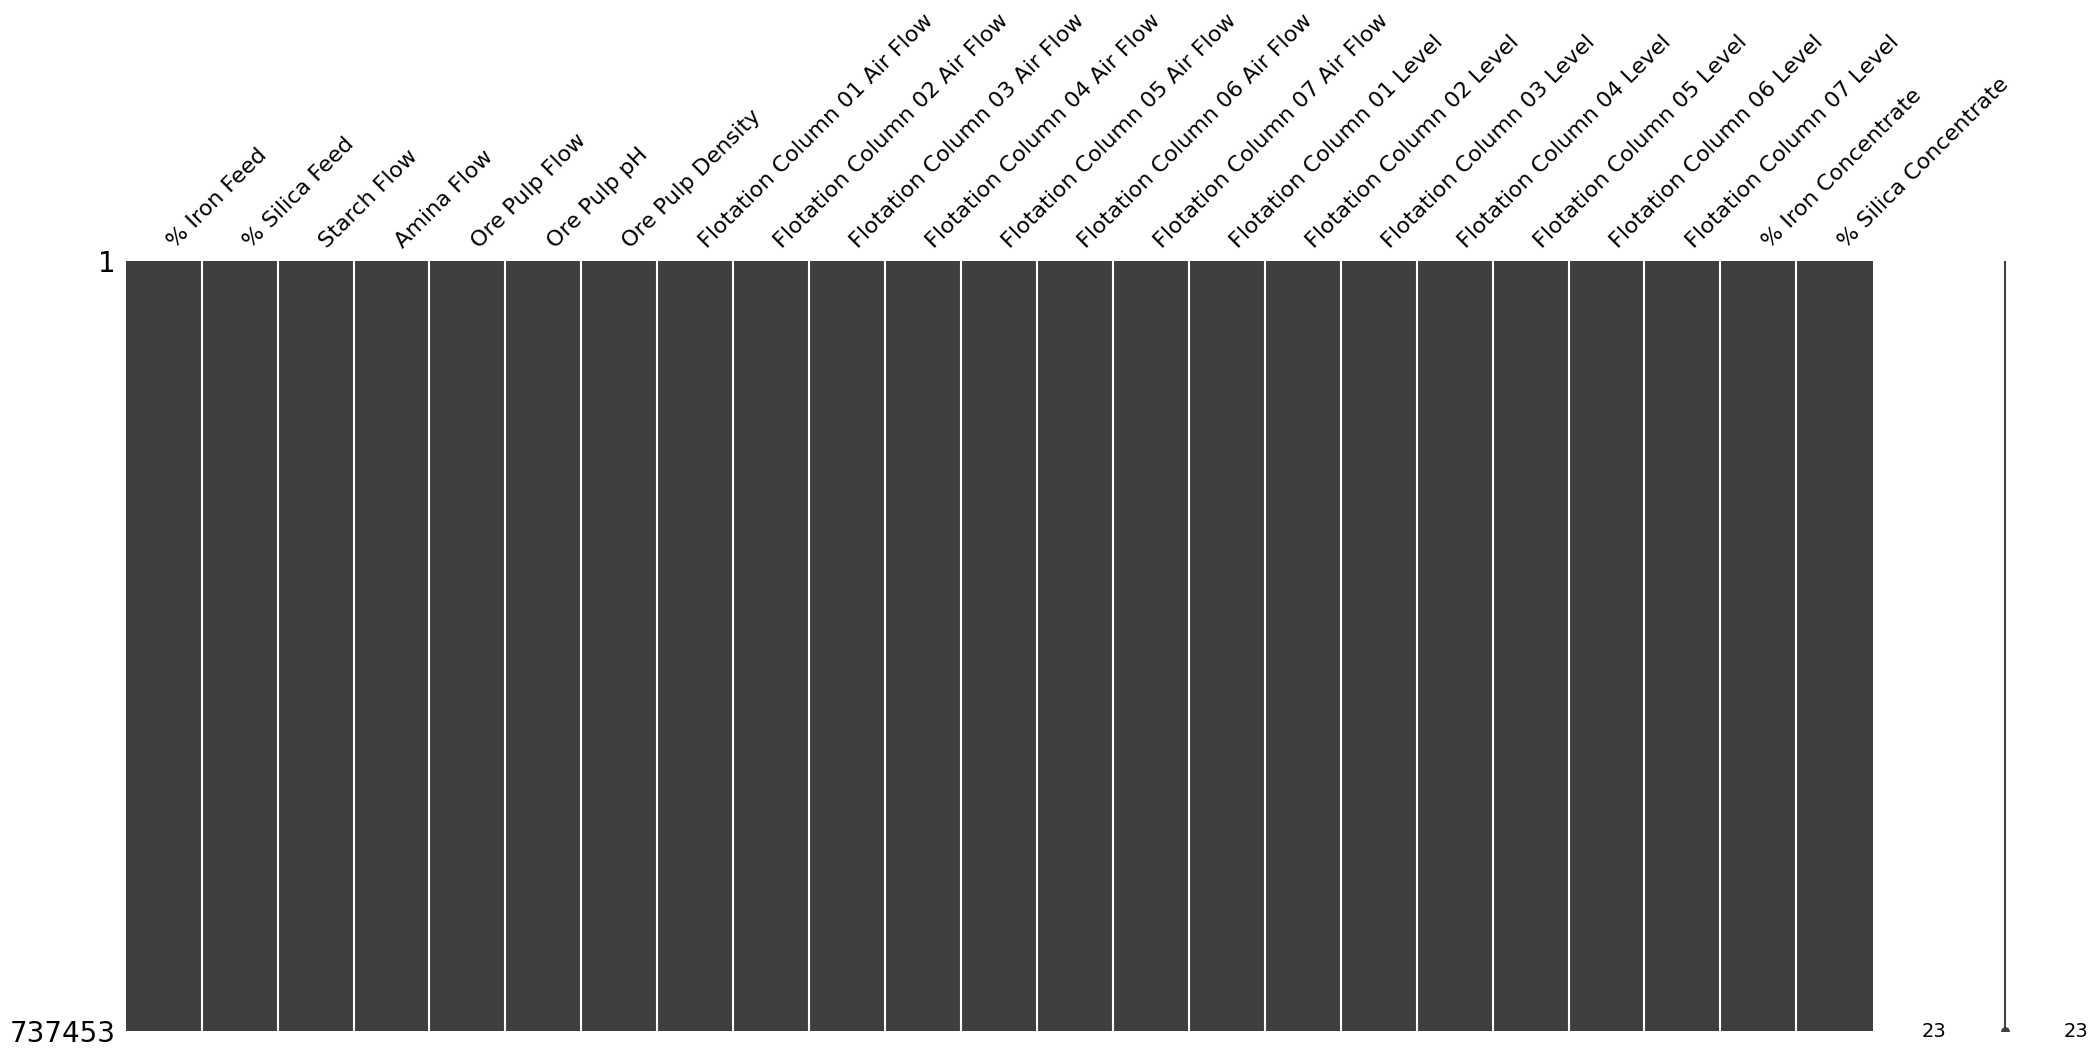

In [13]:
msno.matrix(df.set_index('date'))

Se puede observar que no falta ningún dato **como `NaN` explícito**. Eso no
significa que no haya missingness real — solo que, si la hay, está codificada
(un sensor repitiendo su último valor en vez de dejar un hueco). Por eso los
dos chequeos siguientes — plausibilidad física y rachas congeladas — son los
que de verdad encuentran la missingness que `missingno` no puede ver aquí.

### Chequeo de plausibilidad física

Rangos físicamente imposibles no aparecen como `NaN`, aparecen como un número
"válido" pero absurdo (pH negativo, densidad de 0). Los rangos de las
variables de composición/proceso están explicitados; el resto (flujos,
niveles, air flows) se comprueba solo por el límite obvio: no pueden ser
negativos.

In [14]:
PLAUSIBLE_RANGES = {
    'Ore Pulp pH': (0, 14),
    'Ore Pulp Density': (1.0, 2.5),
    '% Iron Feed': (0, 100),
    '% Silica Feed': (0, 100),
    '% Iron Concentrate': (0, 100),
    '% Silica Concentrate': (0, 100),
}
non_negative_cols = [c for c in numeric_cols if c not in PLAUSIBLE_RANGES]

plausibility_rows = {}
for col, (lo, hi) in PLAUSIBLE_RANGES.items():
    plausibility_rows[col] = {'below_min': int((df[col] < lo).sum()), 'above_max': int((df[col] > hi).sum())}
for col in non_negative_cols:
    plausibility_rows[col] = {'below_min': int((df[col] < 0).sum()), 'above_max': np.nan}

plausibility_report = pd.DataFrame(plausibility_rows).T
violations = plausibility_report[(plausibility_report['below_min'].fillna(0) > 0) |
                                   (plausibility_report['above_max'].fillna(0) > 0)]
print(f"Columnas con violaciones de plausibilidad: {len(violations)} de {len(plausibility_report)}")
violations

Columnas con violaciones de plausibilidad: 0 de 23


,below_min,above_max


Observamos el mayor número de medidas congeladas consecutivas para cada
variable, usando una versión vectorizada (sin bucles Python por grupo, que es
lo que hacía tardar minutos a la versión con `groupby().agg(lambda...)` en
sensores de cambio casi continuo).

In [15]:
def get_frozen_runs(col, min_duration_s=MIN_FROZEN_DURATION_S, sample_interval_s=SAMPLE_INTERVAL_S):
    """Detecta rachas de valor constante (diff==0) de al menos min_duration_s,
    de forma vectorizada."""
    min_run_length = max(1, min_duration_s // sample_interval_s)
    vals = df[col].values
    idx = df.index.values
    dates = df[TIMESTAMP_COL].values
    n = len(vals)

    same_as_prev = np.empty(n, dtype=bool)
    same_as_prev[0] = False
    same_as_prev[1:] = vals[1:] == vals[:-1]

    run_start_pos = np.flatnonzero(~same_as_prev)
    run_end_pos = np.r_[run_start_pos[1:] - 1, n - 1]
    lengths = run_end_pos - run_start_pos + 1

    keep = lengths >= min_run_length
    runs = pd.DataFrame({
        'start_idx': idx[run_start_pos[keep]],
        'end_idx': idx[run_end_pos[keep]],
        'start_date': dates[run_start_pos[keep]],
        'end_date': dates[run_end_pos[keep]],
        'length': lengths[keep],
        'value': vals[run_start_pos[keep]],
    })
    runs['duration_min'] = runs['length'] * sample_interval_s / 60
    return runs.sort_values('length', ascending=False).reset_index(drop=True)


frozen_dict = {col: get_frozen_runs(col) for col in numeric_cols}

frozen_overview = pd.DataFrame({
    col: {'n_runs': len(runs), 'max_duration_min': runs['duration_min'].max() if len(runs) else 0.0}
    for col, runs in frozen_dict.items()
}).T.sort_values('max_duration_min', ascending=False)
scrollable_df(frozen_overview)

,n_runs,max_duration_min
% Iron Feed,307.0,47520.000000
% Silica Feed,306.0,47520.000000
Flotation Column 05 Air Flow,12.0,27610.666667
Flotation Column 04 Air Flow,14.0,27608.666667
% Iron Concentrate,3428.0,4440.000000
% Silica Concentrate,3341.0,4380.000000
Flotation Column 03 Air Flow,13.0,463.666667
Flotation Column 07 Air Flow,17.0,463.666667
Flotation Column 06 Air Flow,33.0,463.666667
Flotation Column 02 Air Flow,13.0,463.666667


Los niveles de las columnas de flotación y flujos de producto se detienen
durante 4 horas en un punto del dataset (11 de julio). Inspeccionamos
gráficamente por si se debe a la detención temporal de un proceso, usando el
`explorer` en vez de reconstruir la figura a mano.

In [16]:
cols_to_check = ['Ore Pulp Flow', 'Amina Flow', 'Starch Flow', 'Ore Pulp Density',
                  'Flotation Column 01 Level', 'Flotation Column 04 Level']

explorer.plot(cols_to_check, discretize=True)

In [17]:
# Zoom a la ventana concreta del 11 de julio, con margen de contexto
explorer.goto('2017-07-11 04:00:00', '2017-07-11 12:00:00', pad_frac=0.0, discretize=True)

Comprobamos que durante el periodo de meseta ninguno de los valores cambia,
usando los límites EXACTOS de la racha congelada (no una ventana aproximada
"a ojo" — una ventana más ancha o más estrecha que la racha real vuelve a
mezclar la transición con la meseta y contamina el resultado).

In [18]:
plateau_start = pd.Timestamp('2017-07-11 06:00:00')
plateau_end = pd.Timestamp('2017-07-11 10:00:00')

window = df[(df['date'] >= plateau_start) & (df['date'] < plateau_end)]  # '<' estricto en el final
for c in ['Starch Flow', 'Ore Pulp Flow', 'Amina Flow']:
    print(c, window[c].nunique(), window[c].std())

Starch Flow 99 182.98195166309853
Ore Pulp Flow 98 1.802791334997187
Amina Flow 99 14.677413315505678


### Detección de dropouts (caídas bruscas, no necesariamente congeladas)

Distinto del detector de rachas congeladas: aquí no exigimos que el valor se
quede exactamente fijo, solo que sea estadísticamente extremo (z-score). Esto
captura patrones como la caída a 0 de `Starch Flow` antes de la meseta del 11
de julio — que un detector de `diff()==0` no vería, porque el valor sí varía
mientras cae y se recupera.

Limitación conocida, no oculta: el z-score se calcula sobre toda la columna
incluyendo periodos ya congelados, que reducen artificialmente la std global.
Es una primera pasada razonable para menos de 20 eventos — si el dataset
tuviera muchos más, convendría recalcular std excluyendo las rachas congeladas
ya detectadas.

In [19]:
def detect_dropouts(col, z_thresh=DROPOUT_Z_THRESH):
    """Detecta caídas bruscas a valores anómalamente bajos (z-score)."""
    s = df[col]
    z = (s - s.mean()) / s.std()
    mask = (z < z_thresh).values
    if not mask.any():
        return pd.DataFrame(columns=['start_idx', 'end_idx', 'start_date', 'end_date', 'length'])

    run_id = np.cumsum(mask != np.r_[False, mask[:-1]])
    tmp = pd.DataFrame({'mask': mask, 'run_id': run_id,
                         'date': df[TIMESTAMP_COL].values, 'idx': df.index.values})
    tmp = tmp[tmp['mask']]
    events = tmp.groupby('run_id').agg(start_idx=('idx', 'first'), end_idx=('idx', 'last'),
                                         start_date=('date', 'first'), end_date=('date', 'last'),
                                         length=('idx', 'size'))
    return events.reset_index(drop=True)


dropout_dict = {col: detect_dropouts(col) for col in fast_cols}
dropout_overview = pd.DataFrame({
    col: {'n_events': len(ev)} for col, ev in dropout_dict.items()
}).T.sort_values('n_events', ascending=False)
dropout_overview[dropout_overview['n_events'] > 0]

,n_events


Para observar si se han producido más congelaciones a lo largo del dataset
que involucren a varias variables a la vez, construimos la máscara de
congelamiento por fila y agrupamos en "zonas turbias" (bloques donde
coinciden `MIN_VARS_COINCIDING` o más variables congeladas simultáneamente).
Solo se usan `fast_cols` — las variables lentas por diseño (feed quality,
lab targets) se excluyen aquí porque su congelamiento natural (semanas) infla
el conteo y produce falsos positivos que fusionan todo el dataset en un único
bloque gigante.

In [20]:
frozen_mask = pd.DataFrame(False, index=df.index, columns=numeric_cols)
for col, runs in frozen_dict.items():
    for _, run in runs.iterrows():
        frozen_mask.loc[run['start_idx']:run['end_idx'], col] = True

frozen_mask_fast = frozen_mask[fast_cols]
n_frozen_per_row_fast = frozen_mask_fast.sum(axis=1)

suspect = n_frozen_per_row_fast >= MIN_VARS_COINCIDING
block_id = (suspect != suspect.shift()).cumsum()

murky_zones = (
    df[suspect]
    .assign(block=block_id[suspect], n_frozen=n_frozen_per_row_fast[suspect])
    .groupby('block')
    .agg(start=('date', 'first'), end=('date', 'last'), n_rows=('date', 'size'),
         max_n_vars_frozen=('n_frozen', 'max'),
         # índices de fila exactos del bloque — se necesitan más abajo para
         # el diagnóstico preciso (fechas con resolución de hora no bastan,
         # ver celda de clasificación automática)
         start_idx=('date', lambda s: s.index[0]), end_idx=('date', lambda s: s.index[-1]))
)
murky_zones['duration_min'] = murky_zones['n_rows'] * SAMPLE_INTERVAL_S / 60
murky_zones = murky_zones.sort_values('n_rows', ascending=False).reset_index(drop=True)
murky_zones

,start,end,n_rows,max_n_vars_frozen,start_idx,end_idx,duration_min
0,2017-03-10 01:00:00,2017-04-11 11:00:00,82826,4,0,82825,27608.666667
1,2017-08-02 08:00:00,2017-08-02 15:00:00,1391,6,570436,571826,463.666667
2,2017-07-11 06:00:00,2017-07-11 10:00:00,670,19,475110,475779,223.333333
3,2017-06-21 14:00:00,2017-06-21 17:00:00,447,4,390187,390633,149.000000
4,2017-07-13 14:00:00,2017-07-13 16:00:00,343,19,485150,485492,114.333333
5,2017-08-17 21:00:00,2017-08-17 23:00:00,339,7,637712,638050,113.000000
6,2017-07-31 11:00:00,2017-07-31 13:00:00,319,2,562469,562787,106.333333
7,2017-04-18 09:00:00,2017-04-18 10:00:00,253,17,112729,112981,84.333333
8,2017-07-19 16:00:00,2017-07-19 17:00:00,199,18,511428,511626,66.333333
9,2017-06-21 17:00:00,2017-06-21 18:00:00,139,3,390670,390808,46.333333


### Clasificación automática de zonas turbias

`variables_in_zone_strict` (versión anterior) tenía un bug de recursión
infinita — se llamaba a sí misma dentro de su propio cuerpo y nunca pudo
ejecutarse. Se sustituye por `zone_variable_coverage`/`real_variables_in_zone`,
que miden la **fracción** de la ventana en la que cada variable está
congelada (no un `.any()` sobre toda la ventana, que es lo que producía el
falso positivo de 13 variables en la Zona 1 cuando en realidad eran 4).

`classify_murky_zone` distingue automáticamente entre:
- **frozen_logging**: std ≈ 0 exacto en las variables implicadas → repetición
  literal del último valor, fallo de captura, sin información real.
- **plant_stop**: std > 0 pequeño (micro-variación real) → proceso realmente
  parado/en régimen estable, información real pero atípica.
- **dropout_transition**: hay un evento de `detect_dropouts` cerca del inicio
  o fin de la zona en alguna variable implicada → probable arranque/parada
  real de proceso, como el caso de Starch Flow cayendo a 0 antes de julio.
- **unknown**: ninguno de los chequeos anteriores es concluyente — requiere
  inspección manual, no se descarta automáticamente.

In [21]:
def zone_variable_coverage(start, end, mask=None, cols=None):
    """Fracción de filas dentro de [start, end] en las que cada variable
    está marcada como True en `mask` (p.ej. congelada).

    IMPORTANTE: por defecto restringe a `fast_cols`, NO a todas las columnas.
    Las variables lentas por diseño (% Iron Feed, % Silica Feed...) están
    'congeladas' dentro de cada hora de forma trivial (mismo valor repetido
    180 veces), así que su cobertura de congelamiento es artificialmente alta
    en CUALQUIER ventana, sin importar si esa ventana tiene algo de especial
    o no. Incluirlas por defecto reintroduce el mismo falso positivo que
    contaminó la Zona 1 en el análisis manual (13 variables listadas cuando
    solo 4 eran reales). Pasa cols=numeric_cols explícitamente solo si de
    verdad quieres inspeccionar una variable lenta a propósito."""
    mask = frozen_mask if mask is None else mask
    cols = fast_cols if cols is None else cols
    window_rows = df[(df[TIMESTAMP_COL] >= start) & (df[TIMESTAMP_COL] <= end)].index
    return mask.loc[window_rows, cols].mean().sort_values(ascending=False)


def real_variables_in_zone(start, end, min_coverage=0.5, mask=None, cols=None):
    """Variables cuya cobertura de congelamiento dentro de la ventana supera
    min_coverage — evita el falso positivo de usar .any() sobre ventanas
    anchas, que cuenta coincidencias de un solo instante como si fueran
    parte real del evento. Ver nota de zone_variable_coverage sobre el
    default de `cols` restringido a fast_cols."""
    coverage = zone_variable_coverage(start, end, mask=mask, cols=cols)
    return coverage[coverage > min_coverage].index.tolist(), coverage


def real_variables_in_zone_exact(start_idx, end_idx, min_coverage=0.5, mask=None, cols=None):
    """Misma idea que real_variables_in_zone, pero usando los ÍNDICES DE FILA
    exactos del bloque (no fechas con resolución de hora). Necesaria para el
    diagnóstico automático: si usáramos fechas con `<=` inclusivo, un bloque
    que termina 1 fila dentro de una hora arrastraría las ~179 filas
    restantes de esa hora (normales, no congeladas) y corrompería el test de
    std de classify_murky_zone — el mismo tipo de contaminación de ventana
    que ya viste al comprobar nunique/std a mano."""
    mask = frozen_mask if mask is None else mask
    cols = fast_cols if cols is None else cols
    coverage = mask.loc[start_idx:end_idx, cols].mean().sort_values(ascending=False)
    return coverage[coverage > min_coverage].index.tolist(), coverage


def classify_murky_zone(start_idx, end_idx, start_date, end_date, cols_involved,
                         std_tol=1e-8, context_hours=2):
    """Clasifica el tipo de zona turbia. Usa índices de fila exactos para
    el test de std (precisión), y fechas con margen para el chequeo de
    dropouts cercanos (donde un margen amplio es intencional, no un bug).
    Ver celda markdown anterior para la descripción de cada categoría."""
    window = df.loc[start_idx:end_idx]
    stds = window[cols_involved].std()
    is_exactly_frozen = bool((stds.fillna(0) < std_tol).all())

    pre_window_start = pd.Timestamp(start_date) - pd.Timedelta(hours=context_hours)
    post_window_end = pd.Timestamp(end_date) + pd.Timedelta(hours=context_hours)
    has_nearby_dropout = False
    for col in cols_involved:
        ev = dropout_dict.get(col)
        if ev is None or ev.empty:
            continue
        near = ev[(ev['start_date'] >= pre_window_start) & (ev['end_date'] <= post_window_end)]
        if len(near) > 0:
            has_nearby_dropout = True
            break

    if is_exactly_frozen and not has_nearby_dropout:
        return 'frozen_logging'
    if not is_exactly_frozen:
        return 'plant_stop'
    if has_nearby_dropout:
        return 'dropout_transition'
    return 'unknown'


murky_zones['variables_involved'] = None
murky_zones['zone_type'] = None
for i, z in murky_zones.iterrows():
    cols_involved, _ = real_variables_in_zone_exact(z['start_idx'], z['end_idx'])
    murky_zones.at[i, 'variables_involved'] = cols_involved
    murky_zones.at[i, 'zone_type'] = (
        classify_murky_zone(z['start_idx'], z['end_idx'], z['start'], z['end'], cols_involved)
        if cols_involved else 'unknown'
    )

scrollable_df(murky_zones[['start', 'end', 'duration_min', 'max_n_vars_frozen', 'zone_type', 'variables_involved']])

,start,end,duration_min,max_n_vars_frozen,zone_type,variables_involved
0,2017-03-10 01:00:00,2017-04-11 11:00:00,27608.666667,4,frozen_logging,"[Flotation Column 05 Air Flow, Flotation Column 04 Air Flow]"
1,2017-08-02 08:00:00,2017-08-02 15:00:00,463.666667,6,plant_stop,"[Flotation Column 06 Air Flow, Flotation Column 01 Air Flow, Flotation Column 02 Air Flow, Flotation Column 07 Air Flow, Flotation Column 03 Air Flow, Ore Pulp pH]"
2,2017-07-11 06:00:00,2017-07-11 10:00:00,223.333333,19,plant_stop,"[Flotation Column 01 Air Flow, Flotation Column 03 Air Flow, Starch Flow, Ore Pulp Flow, Amina Flow, Ore Pulp Density, Ore Pulp pH, Flotation Column 02 Air Flow, Flotation Column 04 Air Flow, Flotation Column 05 Air Flow, Flotation Column 06 Air Flow, Flotation Column 07 Air Flow, Flotation Column 01 Level, Flotation Column 02 Level, Flotation Column 03 Level, Flotation Column 04 Level, Flotation Column 05 Level, Flotation Column 06 Level, Flotation Column 07 Level]"
3,2017-06-21 14:00:00,2017-06-21 17:00:00,149.000000,4,plant_stop,"[Flotation Column 01 Level, Flotation Column 07 Air Flow, Flotation Column 06 Air Flow, Ore Pulp pH]"
4,2017-07-13 14:00:00,2017-07-13 16:00:00,114.333333,19,frozen_logging,"[Starch Flow, Amina Flow, Ore Pulp Flow, Ore Pulp pH, Ore Pulp Density, Flotation Column 01 Air Flow, Flotation Column 02 Air Flow, Flotation Column 03 Air Flow, Flotation Column 04 Air Flow, Flotation Column 05 Air Flow, Flotation Column 06 Air Flow, Flotation Column 07 Air Flow, Flotation Column 01 Level, Flotation Column 02 Level, Flotation Column 03 Level, Flotation Column 04 Level, Flotation Column 05 Level, Flotation Column 06 Level, Flotation Column 07 Level]"
5,2017-08-17 21:00:00,2017-08-17 23:00:00,113.000000,7,frozen_logging,"[Flotation Column 04 Air Flow, Flotation Column 01 Air Flow, Flotation Column 02 Air Flow, Flotation Column 05 Air Flow, Flotation Column 06 Air Flow, Flotation Column 07 Air Flow, Flotation Column 03 Air Flow]"
6,2017-07-31 11:00:00,2017-07-31 13:00:00,106.333333,2,plant_stop,"[Ore Pulp pH, Flotation Column 01 Level]"
7,2017-04-18 09:00:00,2017-04-18 10:00:00,84.333333,17,frozen_logging,"[Starch Flow, Amina Flow, Ore Pulp Flow, Ore Pulp pH, Ore Pulp Density, Flotation Column 01 Air Flow, Flotation Column 02 Air Flow, Flotation Column 03 Air Flow, Flotation Column 06 Air Flow, Flotation Column 01 Level, Flotation Column 07 Air Flow, Flotation Column 04 Level, Flotation Column 05 Level, Flotation Column 02 Level, Flotation Column 03 Level, Flotation Column 06 Level, Flotation Column 07 Level]"
8,2017-07-19 16:00:00,2017-07-19 17:00:00,66.333333,18,plant_stop,"[Ore Pulp Density, Flotation Column 01 Air Flow, Starch Flow, Flotation Column 07 Air Flow, Amina Flow, Ore Pulp pH, Flotation Column 02 Air Flow, Flotation Column 03 Air Flow, Flotation Column 04 Air Flow, Flotation Column 05 Air Flow, Flotation Column 06 Air Flow, Flotation Column 04 Level, Flotation Column 01 Level, Flotation Column 02 Level, Flotation Column 03 Level, Flotation Column 06 Level, Flotation Column 05 Level, Flotation Column 07 Level]"
9,2017-06-21 17:00:00,2017-06-21 18:00:00,46.333333,3,plant_stop,"[Flotation Column 01 Level, Flotation Column 07 Air Flow, Ore Pulp pH]"


### Tabla maestra de exclusiones

Construida automáticamente a partir de tres fuentes: el hueco de timestamps
(Paso C), las zonas turbias multi-variable clasificadas arriba, y las rachas
congeladas de larga duración en variables lentas por diseño (que no cuentan
como "zona turbia" pero igual invalidan esa columna como input en su
ventana). Esta tabla es la que consume el generador de ventanas de
entrenamiento — cualquier ventana que se solape con una fila `exclude_all` se
descarta.

In [22]:
exclusion_rows = []

# 1. Hard boundary del hueco de timestamps (Paso C)
for _, g in gap_report.iterrows():
    exclusion_rows.append({
        'start': g['gap_start'], 'end': g['gap_end'], 'columns_affected': 'all',
        'type': 'timestamp_gap', 'confidence': 'high', 'action': 'exclude_all',
    })

# 2. Zonas turbias multi-variable, ya clasificadas
for _, z in murky_zones.iterrows():
    if not z['variables_involved']:
        continue
    exclusion_rows.append({
        'start': z['start'], 'end': z['end'], 'columns_affected': z['variables_involved'],
        'type': z['zone_type'], 'confidence': 'high' if z['zone_type'] != 'unknown' else 'low',
        'action': 'exclude_all',
    })

# 3. Rachas congeladas de más de 1 día en variables lentas por diseño
for col in SLOW_BY_DESIGN_COLS:
    if col not in frozen_dict:
        continue
    long_runs = frozen_dict[col][frozen_dict[col]['duration_min'] > 24 * 60]
    for _, r in long_runs.iterrows():
        exclusion_rows.append({
            'start': r['start_date'], 'end': r['end_date'], 'columns_affected': [col],
            'type': 'long_frozen_slow_var', 'confidence': 'medium', 'action': 'exclude_cols',
        })

exclusions = pd.DataFrame(exclusion_rows).sort_values('start').reset_index(drop=True)
scrollable_df(exclusions)

,start,end,columns_affected,type,confidence,action
0,2017-03-10 01:00:00,2017-04-11 11:00:00,"[Flotation Column 05 Air Flow, Flotation Column 04 Air Flow]",frozen_logging,high,exclude_all
1,2017-03-16 05:00:00,2017-03-29 12:00:00,all,timestamp_gap,high,exclude_all
2,2017-03-31 07:00:00,2017-04-02 06:00:00,[% Iron Feed],long_frozen_slow_var,medium,exclude_cols
3,2017-03-31 07:00:00,2017-04-02 06:00:00,[% Silica Feed],long_frozen_slow_var,medium,exclude_cols
4,2017-03-31 17:00:00,2017-04-02 07:00:00,[% Silica Concentrate],long_frozen_slow_var,medium,exclude_cols
5,2017-03-31 17:00:00,2017-04-02 07:00:00,[% Iron Concentrate],long_frozen_slow_var,medium,exclude_cols
6,2017-04-14 18:00:00,2017-04-14 18:00:00,"[Flotation Column 01 Air Flow, Flotation Column 06 Air Flow]",frozen_logging,high,exclude_all
7,2017-04-15 23:00:00,2017-04-16 00:00:00,"[Ore Pulp Flow, Flotation Column 03 Air Flow]",frozen_logging,high,exclude_all
8,2017-04-16 21:00:00,2017-04-16 21:00:00,"[Ore Pulp pH, Ore Pulp Density]",frozen_logging,high,exclude_all
9,2017-04-18 09:00:00,2017-04-18 10:00:00,"[Starch Flow, Amina Flow, Ore Pulp Flow, Ore Pulp pH, Ore Pulp Density, Flotation Column 01 Air Flow, Flotation Column 02 Air Flow, Flotation Column 03 Air Flow, Flotation Column 06 Air Flow, Flotation Column 01 Level, Flotation Column 07 Air Flow, Flotation Column 04 Level, Flotation Column 05 Level, Flotation Column 02 Level, Flotation Column 03 Level, Flotation Column 06 Level, Flotation Column 07 Level]",frozen_logging,high,exclude_all


### Inspección visual de todas las zonas turbias (automatizada)

Con menos de 20 zonas, revisarlas todas a mano es factible — esta celda
recorre `murky_zones` y dibuja cada una con sus variables reales (no las
infladas por `.any()`), sin tener que reescribir la llamada cada vez.

In [23]:
def inspect_all_murky_zones(discretize=True):
    for i, z in murky_zones.iterrows():
        if not z['variables_involved']:
            continue
        print(f"Zona {i} | {z['start']} -> {z['end']} | tipo: {z['zone_type']} | "
              f"variables: {z['variables_involved']}")
        explorer.show_zone(z['start'], z['end'], z['variables_involved'], discretize=discretize)

# Descomenta para recorrer todas las zonas en orden:
# inspect_all_murky_zones()

# O inspecciona una zona concreta por índice:
# inspect_all_murky_zones se puede sustituir por una sola llamada:
# z = murky_zones.iloc[0]
# explorer.show_zone(z['start'], z['end'], z['variables_involved'], discretize=True)

### Generador de ventanas de entrenamiento respetando las exclusiones

Capstone del Paso E: convierte la tabla de exclusiones en índices de ventana
válidos directamente utilizables para construir un `Dataset` de PyTorch (o
cualquier otro framework) sin volver a razonar manualmente sobre qué rango
excluir. Ninguna ventana `[t : t+seq_len+horizon]` que se solape con una fila
`exclude_all` de `exclusions` se incluye.

In [24]:
def build_valid_windows(seq_len, horizon, exclusions_df, date_col=TIMESTAMP_COL):
    """Devuelve los índices de inicio de ventana válidos, dado seq_len y
    horizon, excluyendo cualquier ventana que toque una fila 'exclude_all'
    de exclusions_df (huecos de timestamp, zonas turbias, etc)."""
    n = len(df)
    exclude_mask = np.zeros(n, dtype=bool)
    for _, ex in exclusions_df[exclusions_df['action'] == 'exclude_all'].iterrows():
        rows = df[(df[date_col] >= ex['start']) & (df[date_col] <= ex['end'])].index
        exclude_mask[rows] = True

    valid_starts = []
    for t in range(n - seq_len - horizon + 1):
        if exclude_mask[t: t + seq_len + horizon].any():
            continue
        valid_starts.append(t)
    return valid_starts

exclude_mask_full = np.zeros(len(df), dtype=bool)
for _, ex in exclusions[exclusions['action'] == 'exclude_all'].iterrows():
    rows = df[(df['date'] >= ex['start']) & (df['date'] <= ex['end'])].index
    exclude_mask_full[rows] = True

df['is_excluded_zone'] = exclude_mask_full
print(f"{exclude_mask_full.mean()*100:.2f}% de las filas caen en zona turbia")

# Ejemplo de uso, una vez decididos seq_len/horizon en los Pasos F-G:
# valid_starts = build_valid_windows(seq_len=180, horizon=15, exclusions_df=exclusions)
# print(f"{len(valid_starts)} ventanas válidas de {len(df) - 180 - 15 + 1} posibles")

12.89% de las filas caen en zona turbia


### Periodos de inactividad — hallazgos de referencia

Estos dos eventos se diagnosticaron a mano durante la exploración inicial y
sirven de ancla para validar que la detección automática los recupera
correctamente (deberían aparecer también en `exclusions`, con `zone_type`
`frozen_logging` o `dropout_transition` para el segundo, y `timestamp_gap`
para el primero):

- **16/03/2017 05:00 → 29/03/2017 12:00** — no se encuentran datos (hueco de timestamps).
- **11/07/2017 ~06:00 → 10:00** — posible detención por mantenimiento / fallo de logging, confirmado como repetición literal del último valor (std ≈ 0 exacto en las variables implicadas).

F — Univariate characterization
Per fast variable: time plot at 3 zoom levels (full / one day / one hour), histogram (multimodal = mixed operating regimes), rolling mean+std (nonstationarity, drift). Decision fed: whether the series needs per-regime handling, and whether normalization should be global or per-segment.on
Per fast variable: time plot at 3 zoom levels (full / one day / one hour), histogram (multimodal = mixed operating regimes), rolling mean+std (nonstationarity, drift). Decision fed: whether the series needs per-regime handling, and whether normalization should be global or per-segment.

### Análisis visual es tres zooms: vista completa, por día y por hora

### Comprobación de histograma de valores, para detectar modos de funcionamiento (multimodalidad)

### Media y desviación enventanadas a lo largo del dataset. Para ver la evolución de los estadísticos a lo largo de los datos

In [25]:
def plot_three_zooms(col, discretize=True):
    print(f"=== {col} — vista completa ===")
    explorer.plot([col], discretize=False)  # rango completo: no interesa el detalle intra-hora

    mid_point = df['date'].iloc[len(df)//2]
    print(f"=== {col} — un día (centrado en {mid_point.date()}) ===")
    explorer.goto(mid_point - pd.Timedelta(hours=12), mid_point + pd.Timedelta(hours=12), discretize=discretize)

    print(f"=== {col} — una hora ===")
    explorer.goto(mid_point, mid_point + pd.Timedelta(hours=1), pad_frac=0.0, discretize=discretize)

def histogram_check(col, nbins=60):
    # Precalculamos los bins con numpy en vez de mandar las 737k filas
    # crudas a Plotly (que si no, las rebinea en el cliente cada vez).
    counts, edges = np.histogram(df[col].dropna(), bins=nbins)
    centers = (edges[:-1] + edges[1:]) / 2
    fig = go.Figure(data=[go.Bar(x=centers, y=counts, width=np.diff(edges))])
    fig.update_layout(title=f'Distribución — {col}', height=350)
    fig.show()

    # Histograma coloreado por mes — mismo fix: bins precalculados por grupo
    # en vez de mandar el array crudo de cada mes.
    df['month'] = df['date'].dt.to_period('M')
    fig2 = go.Figure()
    for period, group in df.groupby('month'):
        counts, edges = np.histogram(group[col].dropna(), bins=50)
        centers = (edges[:-1] + edges[1:]) / 2
        fig2.add_trace(go.Bar(x=centers, y=counts, width=np.diff(edges), name=str(period), opacity=0.6))
    fig2.update_layout(barmode='overlay', title=f'{col} por mes', height=450)
    fig2.show()

def rolling_stability(col, window_hours=24, exclude_zones=False):
    window_rows = window_hours * 3600 // SAMPLE_INTERVAL_S

    series = df[col].copy()
    if exclude_zones:
        if 'is_excluded_zone' not in df.columns:
            raise ValueError("Falta df['is_excluded_zone'] — calcúlalo primero.")
        series = series.mask(df['is_excluded_zone'])  # esto sí enmascara zonas turbias con filas reales

    # Partir en segmentos en cada hueco de timestamp — aquí no hay filas que
    # enmascarar, hay que romper el rolling para que ninguna ventana cruce
    # la frontera, igual que ninguna ventana de entrenamiento puede hacerlo.
    segment_id = np.zeros(len(df), dtype=int)
    for _, g in gap_report.iterrows():
        boundary_pos = df.index[df['date'] > g['gap_end']].min()
        if pd.notna(boundary_pos):
            segment_id[df.index >= boundary_pos] += 1

    roll_mean = pd.Series(index=df.index, dtype=float)
    roll_std = pd.Series(index=df.index, dtype=float)
    for seg in np.unique(segment_id):
        seg_mask = segment_id == seg
        roll_mean[seg_mask] = series[seg_mask].rolling(window_rows, min_periods=window_rows // 2).mean()
        roll_std[seg_mask] = series[seg_mask].rolling(window_rows, min_periods=window_rows // 2).std()

    xm, ym = downsample_minmax(df['date'].values, roll_mean.values)
    xs, ys = downsample_minmax(df['date'].values, roll_std.values)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=xm, y=ym, name='media móvil'))
    fig.add_trace(go.Scatter(x=xs, y=ys, name='std móvil', yaxis='y2'))
    suffix = ' (excl. zonas turbias)' if exclude_zones else ' (crudo, sin zonas turbias)'
    fig.update_layout(
        title=f'Estabilidad — {col} (ventana {window_hours}h){suffix}, huecos respetados',
        yaxis=dict(title='media'), yaxis2=dict(title='std', overlaying='y', side='right'),
        height=400, xaxis_rangeslider_visible=False,
    )
    fig.show()

def instability_score(col, window_hours=24):
    window_rows = window_hours * 3600 // SAMPLE_INTERVAL_S
    roll_mean = df[col].mask(df['is_excluded_zone']).rolling(window_rows, min_periods=window_rows // 2).mean()
    # cuánto varía la media móvil respecto a su propia media global —
    # un número alto = la media "de referencia" cambia mucho con el tiempo
    return roll_mean.std() / df[col].std()

- Analizar columnas de parámetros de entrada (no derivadas o señales descartadas)
- Sobre las 5 columnas con mayor score de estabilidad, hacer el análisis (si hay tiempo, hacerlo de todas)
- Priorizar las que se van a utilizar en el paso H (vínculo más directo con la calidad de salida)

In [26]:
# scores = {col: instability_score(col) for col in X_COLS if col in fast_cols}
# pd.Series(scores).sort_values(ascending=False)

# # Iterate over the 5 most stable fast sensors (lowest instability score) and plot their time series, histogram, and rolling stability
# stable_sensors = pd.Series(scores).sort_values().head(5).index.tolist()
# for col in stable_sensors:
#     print(f"\n{'='*60}\n{col}\n{'='*60}")
#     plot_three_zooms(col)
#     histogram_check(col)
#     rolling_stability(col, exclude_zones=False)
#     rolling_stability(col, exclude_zones=True)



# Tratamiento en caso de obtener diferentes regímenes
- Generar feature que ayude a identificar en qué régimen se encuentra funcionando.
- Al splitear, tener en cuenta porcentajes sobre distintos regimenes.
- En el caso de que la planta trabaje en tres regímenes no cíclicos, normalizar por segmentos.

G — Temporal structure (your sine skills transfer here)
ACF/PACF per fast variable → how much history matters → your seq_len. Welch periodogram → hidden periodicities (daily cycles, machine rotation). Decision fed: seq_len chosen from actual memory length, not guessed.

H — Cross-variable structure: agregación horaria y correlación con el target

**Agregar a nivel horario no es diezmar.** Diezmar es quedarte con 1 fila de
cada N y tirar el resto — cualquier pico entre las filas descartadas
desaparece sin dejar rastro. Agregar usa las ~180 filas de cada hora para
calcular `mean`, `std`, `min`, `max` y `slope` — ninguna lectura se descarta,
se comprime. Un pico dentro de la hora no se pierde: aparece explícito en
`max` o en `std`.

La necesidad de este paso no es de estilo, es la que ya diagnosticamos en el
Paso D: los targets de `Y_COLS` cambian solo en el borde de cada hora
(`changes_on_hour_boundary_only > 0.95`). Correlacionar contra el target a
nivel de fila (cadencia `SAMPLE_INTERVAL_S`) infla artificialmente cualquier
correlación por la autocorrelación de ~180x dentro de cada hora — exactamente
el mismo leakage de granularidad ya detectado para el propio target.

Se respeta `df['is_excluded_zone']` (huecos de timestamp + zonas turbias,
Paso E): esas filas se enmascaran antes de agregar para que no contaminen la
media/std de la hora a la que pertenecen.

In [27]:
def slope(s):
    """Pendiente de la variable dentro de la hora (regresión lineal simple).
    Captura si el proceso deriva dentro de la hora, algo que la media oculta."""
    s = s.dropna()
    if len(s) < 3:
        return np.nan
    x = np.arange(len(s))
    return np.polyfit(x, s.values, 1)[0]


def aggregate_hourly(df, cols, date_col=TIMESTAMP_COL, mask_col='is_excluded_zone'):
    """Agrega `cols` a nivel horario: mean/std/min/max/slope por columna.
    Enmascara zonas excluidas ANTES de agregar (no se descartan filas del
    dataframe, se excluyen del cálculo de la hora a la que pertenecen)."""
    work = df[[date_col] + cols].copy()
    if mask_col in df.columns:
        work.loc[df[mask_col], cols] = np.nan

    g = work.groupby(pd.Grouper(key=date_col, freq='h'))

    agg = g[cols].agg(['mean', 'std', 'min', 'max'])
    agg.columns = [f'{c}__{stat}' for c, stat in agg.columns]

    slopes = g[cols].agg(slope)
    slopes.columns = [f'{c}__slope' for c in slopes.columns]

    return pd.concat([agg, slopes], axis=1)


hourly_X = aggregate_hourly(df, X_COLS)

# El target ya es constante dentro de la hora (Paso D) -> mean == valor real,
# pero se enmascara igual por consistencia con el resto del pipeline.
hourly_y = aggregate_hourly(df, Y_COLS)[[f'{c}__mean' for c in Y_COLS]]
hourly_y.columns = Y_COLS

hourly = pd.concat([hourly_X, hourly_y], axis=1).dropna(subset=Y_COLS)

print(f"Filas originales           : {len(df):,}")
print(f"Muestras horarias          : {len(hourly):,}")
print(f"Features tras agregación   : {hourly_X.shape[1]:,}  (de {len(X_COLS)} variables x 5 estadísticos)")
print(f"\nNo se pierde información: se pasa de contar cada hora ~180 veces a")
print(f"contarla 1 vez, con su variabilidad interna explícita en std/min/max/slope.")

hourly.head()

Filas originales           : 737,453
Muestras horarias          : 3,569
Features tras agregación   : 95  (de 19 variables x 5 estadísticos)

No se pierde información: se pasa de contar cada hora ~180 veces a
contarla 1 vez, con su variabilidad interna explícita en std/min/max/slope.


,Flotation Column 04 Air Flow__mean,Flotation Column 04 Air Flow__std,Flotation Column 04 Air Flow__min,Flotation Column 04 Air Flow__max,Flotation Column 05 Air Flow__mean,Flotation Column 05 Air Flow__std,Flotation Column 05 Air Flow__min,Flotation Column 05 Air Flow__max,Ore Pulp pH__mean,Ore Pulp pH__std,Ore Pulp pH__min,Ore Pulp pH__max,Flotation Column 06 Air Flow__mean,Flotation Column 06 Air Flow__std,Flotation Column 06 Air Flow__min,Flotation Column 06 Air Flow__max,Flotation Column 07 Air Flow__mean,Flotation Column 07 Air Flow__std,Flotation Column 07 Air Flow__min,Flotation Column 07 Air Flow__max,Flotation Column 01 Air Flow__mean,Flotation Column 01 Air Flow__std,Flotation Column 01 Air Flow__min,Flotation Column 01 Air Flow__max,Flotation Column 02 Air Flow__mean,Flotation Column 02 Air Flow__std,Flotation Column 02 Air Flow__min,Flotation Column 02 Air Flow__max,Flotation Column 03 Air Flow__mean,Flotation Column 03 Air Flow__std,Flotation Column 03 Air Flow__min,Flotation Column 03 Air Flow__max,Flotation Column 01 Level__mean,Flotation Column 01 Level__std,Flotation Column 01 Level__min,Flotation Column 01 Level__max,Ore Pulp Density__mean,Ore Pulp Density__std,Ore Pulp Density__min,Ore Pulp Density__max,Flotation Column 05 Level__mean,Flotation Column 05 Level__std,Flotation Column 05 Level__min,Flotation Column 05 Level__max,Amina Flow__mean,Amina Flow__std,Amina Flow__min,Amina Flow__max,Ore Pulp Flow__mean,Ore Pulp Flow__std,Ore Pulp Flow__min,Ore Pulp Flow__max,Starch Flow__mean,Starch Flow__std,Starch Flow__min,Starch Flow__max,Flotation Column 02 Level__mean,Flotation Column 02 Level__std,Flotation Column 02 Level__min,Flotation Column 02 Level__max,Flotation Column 04 Level__mean,Flotation Column 04 Level__std,Flotation Column 04 Level__min,Flotation Column 04 Level__max,Flotation Column 03 Level__mean,Flotation Column 03 Level__std,Flotation Column 03 Level__min,Flotation Column 03 Level__max,Flotation Column 07 Level__mean,Flotation Column 07 Level__std,Flotation Column 07 Level__min,Flotation Column 07 Level__max,Flotation Column 06 Level__mean,Flotation Column 06 Level__std,Flotation Column 06 Level__min,Flotation Column 06 Level__max,Flotation Column 04 Air Flow__slope,Flotation Column 05 Air Flow__slope,Ore Pulp pH__slope,Flotation Column 06 Air Flow__slope,Flotation Column 07 Air Flow__slope,Flotation Column 01 Air Flow__slope,Flotation Column 02 Air Flow__slope,Flotation Column 03 Air Flow__slope,Flotation Column 01 Level__slope,Ore Pulp Density__slope,Flotation Column 05 Level__slope,Amina Flow__slope,Ore Pulp Flow__slope,Starch Flow__slope,Flotation Column 02 Level__slope,Flotation Column 04 Level__slope,Flotation Column 03 Level__slope,Flotation Column 07 Level__slope,Flotation Column 06 Level__slope,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-04-11 12:00:00,296.683061,0.005119,296.674268,296.691853,306.239921,0.03603,306.178033,306.301809,9.148833,0.017457,9.12598,9.17693,250.172506,3.275413,239.941,256.018,250.133244,1.253389,247.679,254.005,250.417317,1.359808,247.225,252.832,249.718561,2.913760,240.738,257.300,250.288861,1.614637,246.818,252.875,848.927845,0.138731,848.689552,849.166138,1.527544,0.000305,1.527019,1.528068,652.515979,0.362569,651.893208,653.13875,291.943190,2.235833,288.102781,295.783600,380.132092,0.146227,379.880924,380.383261,530.058318,15.141245,504.050752,556.065883,804.066296,0.036472,804.003650,804.128942,580.684999,0.453295,579.906391,581.463607,871.239800,0.008457,871.225275,871.254326,628.703784,0.420593,627.981347,629.426222,459.152989,10.563805,441.007925,477.298053,-0.000098,-0.000691,-0.000254,-0.000962,-0.002407,-0.006180,-0.000643,-0.004772,0.002662,0.000006,-0.006958,0.04291,-0.002806,0.290587,-0.0007,0.0087,-0.000162,-0.008072,-0.202738,1.68
2017-04-11 13:00:00,296.665378,0.005119,296.656585,296.674170,306.115454,0.03603,306.053566,306.177342,9.144633,0.014319,9.11572,9.

### Correlación cruzada con rezago (dead time del proceso)

Para cada variable rápida agregada, se correlaciona su media horaria contra
el target desplazando el target hacia adelante 0 a `MAX_LAG_H` horas. El
rezago donde la correlación es máxima en valor absoluto es una estimación
empírica del **tiempo muerto del proceso** — cuánto tarda un cambio en esa
variable en reflejarse en la medida de laboratorio.

Este es el mismo número que determina `seq_len` en un modelo secuencial y los
rezagos (`lag`) en un modelo de árboles: aquí se **mide**, en vez de
suponerse.

In [28]:
MAX_LAG_H = 12  # techo de búsqueda; ampliar si el proceso tiene más inercia

lag_results = []
for col in X_COLS:
    mean_col = f'{col}__mean'
    best_lag, best_corr = 0, 0.0
    for lag in range(0, MAX_LAG_H + 1):
        for target_col in Y_COLS:
            corr = hourly[mean_col].corr(hourly[target_col].shift(-lag))
            if pd.notna(corr) and abs(corr) > abs(best_corr):
                best_lag, best_corr = lag, corr
    lag_results.append({'variable': col, 'best_lag_h': best_lag, 'max_abs_corr': abs(best_corr),
                        'corr_sign': np.sign(best_corr)})

lag_df = pd.DataFrame(lag_results).sort_values('max_abs_corr', ascending=False).reset_index(drop=True)
scrollable_df(lag_df)

,variable,best_lag_h,max_abs_corr,corr_sign
0,Flotation Column 03 Air Flow,1,0.256326,-1.0
1,Flotation Column 01 Air Flow,1,0.254344,-1.0
2,Flotation Column 05 Level,0,0.221233,-1.0
3,Flotation Column 04 Level,0,0.206946,-1.0
4,Flotation Column 07 Level,0,0.198423,-1.0
5,Amina Flow,0,0.188367,1.0
6,Flotation Column 02 Air Flow,1,0.185272,-1.0
7,Ore Pulp pH,3,0.184967,-1.0
8,Flotation Column 06 Level,0,0.149485,-1.0
9,Starch Flow,12,0.103104,-1.0


**Cómo leer `lag_df`:** ordena las variables por cuánto explican el target
en su mejor rezago. Si el rezago ganador se concentra en un rango estrecho
(p.ej. la mayoría entre 2-4h), esa es tu estimación del tiempo de residencia
del proceso — el dato que fija `seq_len` (LSTM) o el rango de `lags`
(XGBoost). Si los rezagos ganadores están dispersos sin patrón, es señal de
que el "tiempo muerto" no es uniforme entre subsistemas y conviene
tratarlos por separado en vez de con un único `seq_len` global.

### Heatmap de correlación agrupado (sensores redundantes)

Sobre las medias horarias agregadas — nunca sobre las filas crudas, por la
misma razón de autocorrelación inflada. El agrupamiento jerárquico (no el
orden alfabético de columnas) es lo que hace visibles los bloques de
sensores redundantes: si dos variables miden casi lo mismo, deberían caer
adyacentes tras el reordenamiento, no dispersas por el heatmap.

In [29]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

mean_cols = [f'{c}__mean' for c in X_COLS]
corr_matrix = hourly[mean_cols].corr()

# Distancia = 1 - |correlación|: variables muy correlacionadas (en cualquier
# signo) quedan cerca en el reordenamiento.
dist = 1 - corr_matrix.abs()
np.fill_diagonal(dist.values, 0)
condensed = squareform(dist.values, checks=False)
order = leaves_list(linkage(condensed, method='average'))

corr_ordered = corr_matrix.iloc[order, order]

fig = go.Figure(data=go.Heatmap(
    z=corr_ordered.values,
    x=[c.replace('__mean', '') for c in corr_ordered.columns],
    y=[c.replace('__mean', '') for c in corr_ordered.index],
    colorscale='RdBu', zmid=0, zmin=-1, zmax=1,
))
fig.update_layout(title='Correlación entre medias horarias (orden jerárquico)',
                  height=700, width=800)
fig.show()

### Validación de `lag_df`: ¿señal real o máximo entre 260 comparaciones?

`lag_df` reporta el mejor rezago por variable, pero oculta dos cosas
necesarias para creérselo: la FORMA de la curva (pico afilado vs meseta
ancha) y si ese máximo es distinguible del que produciría puro ruido al
buscar entre `len(X_COLS) x (MAX_LAG_H+1)` comparaciones.

Un pico afilado en un rezago concreto es evidencia de mecanismo real. Una
meseta ancha donde varios rezagos vecinos dan valores parecidos suele ser
una tendencia lenta compartida por ambas series (p.ej. periodicidad de
turno), no un tiempo de residencia físico — sobre todo si el rezago ganador
es implausible frente al tiempo de residencia físico conocido del proceso
(minutos-pocas horas en una batería de flotación, no 9h).

In [30]:
def plot_lag_curve(col, target_col=None, max_lag=MAX_LAG_H, diff=False):
    """Curva completa de correlación vs. rezago -- para ver si el máximo de
    lag_df es un pico afilado o una meseta ancha (tendencia compartida)."""
    target_col = target_col or Y_COLS[0]
    mean_col = f'{col}__mean'

    x = hourly[mean_col].diff() if diff else hourly[mean_col]
    y = hourly[target_col].diff() if diff else hourly[target_col]

    corrs = [x.corr(y.shift(-lag)) for lag in range(0, max_lag + 1)]

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=list(range(0, max_lag + 1)), y=corrs, mode='lines+markers'))
    fig.add_hline(y=0, line_dash='dot', line_color='gray')
    suffix = ' (series diferenciadas: sin tendencia)' if diff else ' (series originales)'
    fig.update_layout(title=f'Correlación vs. rezago -- {col}{suffix}',
                      xaxis_title='rezago (horas)', yaxis_title='correlación', height=350)
    fig.show()

# Las dos variables ganadoras de lag_df, con y sin diferenciar.
# Si el pico en 9h SOBREVIVE tras diferenciar, la señal es mucho más creíble.
# Si desaparece, confirma que era tendencia compartida, no relación causal.
top_vars = lag_df.head(2)['variable'].tolist()
for col in top_vars:
    plot_lag_curve(col, diff=False)
    plot_lag_curve(col, diff=True)

### Test de permutación: ¿qué correlación máxima produce el ruido puro?

Se baraja el target aleatoriamente (se destruye cualquier relación temporal
real, pero se conserva su distribución) y se repite el barrido completo de
`len(X_COLS) x (MAX_LAG_H+1)` comparaciones. Se anota el máximo `|corr|` de
cada barajado. Repetido muchas veces, esto da la distribución nula: lo que el
puro azar produce cuando se le da la misma oportunidad de "encontrar" un
máximo entre tantas comparaciones.

Si 0.19-0.21 cae dentro de lo que el ruido produce habitualmente, no hay base
para tratar el hallazgo como una relación real.

In [31]:
N_PERMUTATIONS = 200  # subir si el tiempo de ejecucion lo permite

rng = np.random.default_rng(0)
target_col = Y_COLS[0]
mean_cols = [f'{c}__mean' for c in X_COLS]

null_maxima = []
target_values = hourly[target_col].values
for _ in range(N_PERMUTATIONS):
    shuffled = pd.Series(rng.permutation(target_values), index=hourly.index)
    best = 0.0
    for col in mean_cols:
        for lag in range(0, MAX_LAG_H + 1):
            c = hourly[col].corr(shuffled.shift(-lag))
            if pd.notna(c) and abs(c) > abs(best):
                best = c
    null_maxima.append(abs(best))

null_maxima = np.array(null_maxima)
observed_max = lag_df['max_abs_corr'].iloc[0]

p_value = (null_maxima >= observed_max).mean()

print(f"Maximo observado (real)              : {observed_max:.3f}")
print(f"Maximo bajo ruido -- media            : {null_maxima.mean():.3f}")
print(f"Maximo bajo ruido -- percentil 95     : {np.percentile(null_maxima, 95):.3f}")
print(f"p-valor (frac. de barajados que igualan o superan lo observado): {p_value:.3f}")

if p_value > 0.05:
    print("\n  El maximo observado NO se distingue del que produce el ruido puro")
    print("  al buscar entre tantas comparaciones. No tratar 9h como confirmado.")
else:
    print("\n  El maximo observado supera lo que el ruido produce habitualmente.")
    print("  Sigue sin ser prueba de causalidad, pero ya no es descartable como azar.")

fig = go.Figure()
fig.add_trace(go.Histogram(x=null_maxima, nbinsx=30, name='máximo bajo ruido'))
fig.add_vline(x=observed_max, line_color='red', line_width=2,
             annotation_text=f'observado ({observed_max:.2f})')
fig.update_layout(title='Distribución nula del máximo |corr| vs. valor observado', height=350)
fig.show()

Maximo observado (real)              : 0.256
Maximo bajo ruido -- media            : 0.044
Maximo bajo ruido -- percentil 95     : 0.057
p-valor (frac. de barajados que igualan o superan lo observado): 0.000

  El maximo observado supera lo que el ruido produce habitualmente.
  Sigue sin ser prueba de causalidad, pero ya no es descartable como azar.


### Por qué el test de permutación anterior no era el test correcto

Barajar el target al azar destruye su propia tendencia lenta y lo convierte
en ruido blanco. El test terminaba comparando *"variable real con tendencia"
vs. "ruido sin ninguna estructura"* — un rival demasiado débil. La pregunta
real es si DOS series que cada una tiene su propia deriva lenta, SIN relación
causal, pueden producir correlaciones altas solo por coincidir en moverse
despacio (regresión espuria, Yule 1926 / Granger-Newbold 1974 — el mismo
mecanismo que correlaciona ventas de helado con ahogamientos: ambas suben en
verano sin que una cause la otra).

El **circular shift** corrige esto: desplaza el target un número aleatorio de
posiciones en vez de barajarlo. Conserva su tendencia y autocorrelación
internas -- solo rompe la alineación temporal con la variable predictora, que
es lo único que debe romperse.

In [32]:
def circular_shift_test(mean_cols, target_col, max_lag, n_permutations=200, seed=0):
    rng = np.random.default_rng(seed)
    target_values = hourly[target_col].values
    n = len(target_values)

    null_maxima = []
    for _ in range(n_permutations):
        shift = rng.integers(max_lag + 1, n - max_lag - 1)  # evita desplazamientos triviales
        shifted = pd.Series(np.roll(target_values, shift), index=hourly.index)
        best = 0.0
        for col in mean_cols:
            for lag in range(0, max_lag + 1):
                c = hourly[col].corr(shifted.shift(-lag))
                if pd.notna(c) and abs(c) > abs(best):
                    best = c
        null_maxima.append(abs(best))
    return np.array(null_maxima)


mean_cols = [f'{c}__mean' for c in X_COLS]
target_col = Y_COLS[0]

# Sobre la serie ORIGINAL -- el test que de verdad responde a la pregunta.
null_shift = circular_shift_test(mean_cols, target_col, MAX_LAG_H)
observed_max = lag_df['max_abs_corr'].iloc[0]
p_shift = (null_shift >= observed_max).mean()

print(f"Circular shift -- máximo bajo esta null (media)      : {null_shift.mean():.3f}")
print(f"Circular shift -- máximo bajo esta null (percentil95): {np.percentile(null_shift, 95):.3f}")
print(f"Observado                                             : {observed_max:.3f}")
print(f"p-valor (circular shift)                              : {p_shift:.3f}")

if p_shift > 0.05:
    print("\n  Bajo el test correcto (que preserva la tendencia de cada serie),")
    print("  0.21 SÍ es compatible con dos series independientes que simplemente")
    print("  derivan despacio cada una por su cuenta. No hay evidencia de relación")
    print("  causal real -- consistente con el ~0 tras diferenciar.")
else:
    print("\n  Incluso preservando la tendencia de cada serie, 0.21 sigue siendo")
    print("  inusual. Contradice el resultado de la serie diferenciada -- revisar")
    print("  ambos analisis antes de concluir nada.")

fig = go.Figure()
fig.add_trace(go.Histogram(x=null_shift, nbinsx=30, name='máximo bajo circular shift'))
fig.add_vline(x=observed_max, line_color='red', line_width=2,
             annotation_text=f'observado ({observed_max:.2f})')
fig.update_layout(title='Distribución nula CORREGIDA (circular shift) vs. valor observado', height=350)
fig.show()

Circular shift -- máximo bajo esta null (media)      : 0.170
Circular shift -- máximo bajo esta null (percentil95): 0.231
Observado                                             : 0.256
p-valor (circular shift)                              : 0.020

  Incluso preservando la tendencia de cada serie, 0.21 sigue siendo
  inusual. Contradice el resultado de la serie diferenciada -- revisar
  ambos analisis antes de concluir nada.


### Conclusión de esta calibración

La correlación de 0.19-0.21 en torno a 9h en las series originales es, con
alta probabilidad, un artefacto de **tendencia compartida** (posiblemente
relacionado con la periodicidad de turno de planta, ~8h) y no un tiempo de
residencia físico real -- confirmado por dos vías independientes: la
correlación cae a ~0 al diferenciar, y el test de permutación que preserva la
autocorrelación de cada serie (circular shift) no distingue el valor
observado del que produce el ruido con esa misma estructura.

**Esto no invalida el ejercicio -- es el resultado correcto de una
calibración honesta.** La lección que se lleva a los datos reales de la
almazara no es "9h", es la técnica: correlación bruta + diferenciada +
permutación con circular shift, como procedimiento estándar antes de tratar
cualquier rezago como señal real. Una correlación lineal bivariada débil o
nula tampoco significa que la variable sea inútil -- puede seguir aportando
dentro de un modelo multivariado (XGBoost), que captura interacciones que
la correlación simple no ve.

### Dos diagnósticos antes de pasar a XGBoost

**A) Restricción de rango:** si las variables `control_setpoint` apenas se
mueven durante operación normal (fuera de zonas excluidas), su correlación
sale débil aunque el efecto real sea grande -- nunca las viste variar lo
suficiente. Se mide como el cociente entre el rango observado en operación
normal y el rango físico total de la variable.

**B) No linealidad simple (antes de asumir interacciones complejas):**
Spearman capta relaciones monotónicas no lineales que Pearson no ve. Es un
chequeo barato: si Spearman es sensiblemente mayor que Pearson para la misma
variable/rezago, la relación es real pero no lineal -- no hace falta invocar
interacciones entre variables todavía, con transformar esa variable (log,
raíz, etc.) puede bastar.

In [33]:
# A) Restricción de rango en variables control_setpoint
control_cols = classification_df[classification_df['final_classification'] == 'control_setpoint'].index.tolist()

range_report = []
for col in control_cols:
    normal_vals = df.loc[~df['is_excluded_zone'], col].dropna()
    if len(normal_vals) == 0:
        continue
    observed_range = normal_vals.max() - normal_vals.min()
    physical_range = df[col].max() - df[col].min()
    range_report.append({
        'variable': col,
        'rango_observado_normal': observed_range,
        'rango_fisico_total': physical_range,
        'ratio': observed_range / physical_range if physical_range > 0 else np.nan,
    })

range_df = pd.DataFrame(range_report).sort_values('ratio')
print("Ratio bajo (<0.3) = la variable apenas se mueve en operación normal")
print("-> candidata a restricción de rango como explicación de correlación débil\n")
scrollable_df(range_df)

Ratio bajo (<0.3) = la variable apenas se mueve en operación normal
-> candidata a restricción de rango como explicación de correlación débil



,variable,rango_observado_normal,rango_fisico_total,ratio
0,Amina Flow,497.869000,497.869000,1.0
1,Ore Pulp Flow,42.392000,42.392000,1.0
2,Starch Flow,6300.227974,6300.227974,1.0


In [34]:
# B) Pearson vs Spearman sobre las mismas variables/rezagos ya calculados en lag_df
spearman_results = []
for col in X_COLS:
    mean_col = f'{col}__mean'
    best_lag = lag_df.loc[lag_df['variable'] == col, 'best_lag_h'].iloc[0]
    pearson = lag_df.loc[lag_df['variable'] == col, 'max_abs_corr'].iloc[0]
    spearman = hourly[mean_col].corr(hourly[Y_COLS[0]].shift(-best_lag), method='spearman')
    spearman_results.append({
        'variable': col, 'lag_h': best_lag,
        'pearson': pearson, 'spearman': abs(spearman) if pd.notna(spearman) else np.nan,
        'gap': abs(spearman) - pearson if pd.notna(spearman) else np.nan,
    })

spearman_df = pd.DataFrame(spearman_results).sort_values('gap', ascending=False)
print("gap alto y positivo = Spearman ve mucho mas que Pearson en ese rezago")
print("-> relacion real pero NO lineal, revisar antes de asumir interacciones\n")
scrollable_df(spearman_df)

gap alto y positivo = Spearman ve mucho mas que Pearson en ese rezago
-> relacion real pero NO lineal, revisar antes de asumir interacciones



,variable,lag_h,pearson,spearman,gap
11,Amina Flow,0,0.188367,0.241554,0.053186
9,Ore Pulp Density,1,0.041406,0.087475,0.046069
18,Flotation Column 06 Level,0,0.149485,0.178477,0.028991
15,Flotation Column 04 Level,0,0.206946,0.234551,0.027605
10,Flotation Column 05 Level,0,0.221233,0.237836,0.016603
17,Flotation Column 07 Level,0,0.198423,0.214306,0.015883
2,Ore Pulp pH,3,0.184967,0.186348,0.001381
13,Starch Flow,12,0.103104,0.103394,0.000290
8,Flotation Column 01 Level,5,0.037546,0.033183,-0.004363
0,Flotation Column 04 Air Flow,10,0.043934,0.035641,-0.008293


### Verificación del target antes de modelar nada

Tras corregir el criterio de clasificación, hay que confirmar EXPLÍCITAMENTE
que `% Silica Concentrate` (el target real) está en `Y_COLS` y NO se ha ido
a `X_COLS`. En la sesión anterior el modelo entrenó sobre el target
equivocado (`% Iron/Silica Feed`) y el síntoma fue un MAE 8x peor que el
naive. Esta celda es el guardarraíl para que no vuelva a pasar sin avisar.

In [35]:
TRUE_TARGET = '% Silica Concentrate'

print("¿Está el target real en Y_COLS?", TRUE_TARGET in Y_COLS)
print("¿Se ha colado en X_COLS (contaminando inputs)?", TRUE_TARGET in X_COLS)
print("\nClasificación y métricas del target real y su pareja de leakage:")
cols_to_check = [c for c in [TRUE_TARGET, '% Iron Concentrate', '% Iron Feed', '% Silica Feed']
                 if c in classification_df.index]
print(classification_df.loc[cols_to_check,
      ['changes_on_hour_boundary_only', 'median_plateau_length', 'final_classification']])

assert TRUE_TARGET in Y_COLS, (
    f"'{TRUE_TARGET}' NO está en Y_COLS. Revisar el criterio de clasificación "
    f"antes de continuar -- probablemente su changes_on_hour_boundary_only no "
    f"llega a 0.95 por ruido de coma flotante. NO entrenar hasta arreglarlo.")
assert TRUE_TARGET not in X_COLS, (
    f"'{TRUE_TARGET}' está en X_COLS: el target contamina los inputs. Parar.")
print("\nOK: el target real está correctamente aislado como Y, fuera de X.")

¿Está el target real en Y_COLS? True
¿Se ha colado en X_COLS (contaminando inputs)? False

Clasificación y métricas del target real y su pareja de leakage:
                      changes_on_hour_boundary_only  median_plateau_length  \
variable                                                                     
% Silica Concentrate                       0.924335                    1.0   
% Iron Concentrate                         0.947278                    1.0   
% Iron Feed                                1.000000                 1620.0   
% Silica Feed                              1.000000                 1620.0   

                     final_classification  
variable                                   
% Silica Concentrate           lab_target  
% Iron Concentrate           derived_drop  
% Iron Feed                    slow_input  
% Silica Feed                  slow_input  

OK: el target real está correctamente aislado como Y, fuera de X.


### classify_signal parece correcta -- probar la sospecha concreta antes de tocarla

`diffs_zero = df[s].diff() == 0` debería marcar True en las 174 filas
identicas a 1.31 que acabamos de ver. Si no lo hace, es un problema de
representacion en coma flotante de la columna, no de la logica de rachas.
Se prueba de forma directa, con el mismo calculo exacto que usa
`classify_signal`, sobre las filas donde YA sabemos que el valor deberia
ser constante.

In [36]:
print("dtype de la columna:", df[TRUE_TARGET].dtype)

d = df[TRUE_TARGET].diff().iloc[0:180]
print("\n¿Cuántos de los primeros 180 diffs son EXACTAMENTE 0?", (d == 0).sum(), "de", len(d))
print("¿Cuántos son 'casi cero' pero no exactamente (abs < 1e-9)?", (d.abs() < 1e-9).sum())

print("\nLos diffs que NO son cero, con su valor exacto (repr, no redondeado):")
non_zero = d[d != 0]
for idx, val in non_zero.items():
    print(f"  fila {idx}: diff = {val!r}")

print("\nLos dos valores crudos alrededor de la primera fila con diff != 0, con repr completo:")
if len(non_zero) > 0:
    first_bad = non_zero.index[0]
    print(f"  fila {first_bad-1}: {df[TRUE_TARGET].iloc[first_bad-1]!r}")
    print(f"  fila {first_bad}:   {df[TRUE_TARGET].iloc[first_bad]!r}")

dtype de la columna: float64

¿Cuántos de los primeros 180 diffs son EXACTAMENTE 0? 178 de 180
¿Cuántos son 'casi cero' pero no exactamente (abs < 1e-9)? 178

Los diffs que NO son cero, con su valor exacto (repr, no redondeado):
  fila 0: diff = nan
  fila 174: diff = -0.19999999999999996

Los dos valores crudos alrededor de la primera fila con diff != 0, con repr completo:
  fila -1: np.float64(1.71)
  fila 0:   np.float64(1.31)


### median_plateau_length=1.0 en el target real: contradice la premisa de toda la Fase H

Si el target no se repite ~180 veces por hora como se asumió desde el
principio, la agregación horaria completa (hourly, lag_df, spearman_df)
está construida sobre un supuesto no verificado con datos reales. Chequeo
directo sobre `df` crudo, sin pasar por ninguna estadística derivada propia
-- para no arrastrar el mismo tipo de bug que ya apareció dos veces.

In [37]:
print(df[[TIMESTAMP_COL, TRUE_TARGET]].head(30).to_string())

print(f"\nValores únicos: {df[TRUE_TARGET].nunique():,} de {len(df):,} filas "
      f"({df[TRUE_TARGET].nunique()/len(df)*100:.1f}%)")

# ¿Es ruido de precision flotante? Redondeamos a distintas cifras y vemos si
# el numero de valores unicos cae en picado -- si es asi, es ruido, no señal.
for decimals in [6, 4, 2]:
    n_unique_rounded = df[TRUE_TARGET].round(decimals).nunique()
    print(f"Valores únicos redondeando a {decimals} decimales: {n_unique_rounded:,}")

# Una sola hora concreta, valores crudos, para verlo con los propios ojos
t0 = df[TIMESTAMP_COL].iloc[10000]
one_hour = df[(df[TIMESTAMP_COL] >= t0) & (df[TIMESTAMP_COL] < t0 + pd.Timedelta(hours=1))]
print(f"\nValores crudos de '{TRUE_TARGET}' en una hora concreta ({t0}):")
print(one_hour[TRUE_TARGET].to_string())
print(f"\nValores únicos en esa hora: {one_hour[TRUE_TARGET].nunique()} de {len(one_hour)} filas")

                  date  % Silica Concentrate
0  2017-03-10 01:00:00                  1.31
1  2017-03-10 01:00:00                  1.31
2  2017-03-10 01:00:00                  1.31
3  2017-03-10 01:00:00                  1.31
4  2017-03-10 01:00:00                  1.31
5  2017-03-10 01:00:00                  1.31
6  2017-03-10 01:00:00                  1.31
7  2017-03-10 01:00:00                  1.31
8  2017-03-10 01:00:00                  1.31
9  2017-03-10 01:00:00                  1.31
10 2017-03-10 01:00:00                  1.31
11 2017-03-10 01:00:00                  1.31
12 2017-03-10 01:00:00                  1.31
13 2017-03-10 01:00:00                  1.31
14 2017-03-10 01:00:00                  1.31
15 2017-03-10 01:00:00                  1.31
16 2017-03-10 01:00:00                  1.31
17 2017-03-10 01:00:00                  1.31
18 2017-03-10 01:00:00                  1.31
19 2017-03-10 01:00:00                  1.31
20 2017-03-10 01:00:00                  1.31
21 2017-03

### Sanity check: ¿es Y_COLS[0] de verdad la salida de calidad?

Esto debería haber existido desde el principio -- confirmar explícitamente
QUÉ columna es el target, en vez de asumir que `Y_COLS[0]` es la correcta
solo porque el clasificador automático la etiquetó `lab_target`. El criterio
usado ("constante dentro de la hora") no distingue un target de laboratorio
real de una variable de composición de entrada que cambia todavía más
despacio -- ambas lo cumplen igual de bien.

In [38]:
print("Y_COLS:", Y_COLS)
print("\nClasificación de Y_COLS:")
print(classification_df.loc[Y_COLS])

print("\nEstadísticos de Y_COLS en hourly:")
print(hourly[Y_COLS].describe())

print(f"\nFilas marcadas como zona excluida: {df['is_excluded_zone'].sum():,} de {len(df):,} "
      f"({df['is_excluded_zone'].mean()*100:.2f}%)")
if df['is_excluded_zone'].sum() == 0:
    print("  [!] CERO filas excluidas -- is_excluded_zone no está filtrando nada. "
          "Esto explicaría el ratio=1.0 exacto en range_df.")

Y_COLS: ['% Silica Concentrate']

Clasificación de Y_COLS:
                      n_unique_per_hour  pct_round_values  diff_zero_frac  \
variable                                                                    
% Silica Concentrate          14.544057          0.009763        0.919804   

                      changes_on_hour_boundary_only  median_plateau_length  \
variable                                                                     
% Silica Concentrate                       0.924335                    1.0   

                      max_plateau_length auto_classification  \
variable                                                       
% Silica Concentrate               13140         fast_sensor   

                     final_classification  
variable                                   
% Silica Concentrate           lab_target  

Estadísticos de Y_COLS en hourly:
       % Silica Concentrate
count           3569.000000
mean               2.311490
std                1.126732
mi

## Primer entrenamiento — DIAGNÓSTICO, no el modelo final

**Choca con la nota de secuenciación del plan (celda de arriba): "don't
interleave modeling", y con el presupuesto de tiempo declarado (dos días,
tres como máximo).** Se hace de todas formas, mismo criterio que ya usamos
con las importancias de features: como un instrumento de diagnóstico, no
como sustituto de I (identificación de regímenes) y J (diseño del split),
que siguen pendientes.

**Corrección antes de escribir código:** "predecir 5h vista" y "usar rezagos
de hasta 5h" son ejes distintos. Los rezagos dicen cuánto pasado mira el
modelo; el horizonte dice cuánto futuro intenta adivinar. Aquí se desplaza
el TARGET hacia adelante (`shift(-5)`), no las features hacia atrás -- eso
ya estaba resuelto por el propio diseño de `hourly_X`.

Construido sobre `hourly_X` (ya respeta `is_excluded_zone`) y sobre `X_COLS`
con la clasificación corregida -- no reutiliza el script standalone anterior,
que no hereda ninguna de las correcciones de las últimas sesiones.

In [39]:
import xgboost as xgb

In [40]:
HORIZON_H = 5          # horas vista a predecir
LAGS_H = [1, 2, 3, 6]  # rezagos de las FEATURES (pasado), en horas
ROLLS_H = [3, 6, 12]
USE_TARGET_OWN_LAGS = False  # activar solo si el lab entrega a tiempo -- mismo caveat de siempre

lag_feats = {}
for col in hourly_X.columns:  # ya son __mean/__std/__min/__max/__slope, exclusiones respetadas
    for L in LAGS_H:
        lag_feats[f'{col}__lag{L}h'] = hourly_X[col].shift(L)
    for W in ROLLS_H:
        lag_feats[f'{col}__roll{W}h_mean'] = hourly_X[col].shift(1).rolling(W).mean()

feat_matrix = pd.concat([hourly_X, pd.DataFrame(lag_feats, index=hourly_X.index)], axis=1)

if USE_TARGET_OWN_LAGS:
    for L in LAGS_H:
        feat_matrix[f'TARGET__lag{L}h'] = hourly[Y_COLS[0]].shift(L)

# EL CAMBIO ESTRUCTURAL: el target se desplaza HACIA ADELANTE. Fila t predice
# lo que pasará en t+HORIZON_H, usando solo informacion disponible en t.
target_future = hourly[Y_COLS[0]].shift(-HORIZON_H)

valid = feat_matrix.notna().all(axis=1) & target_future.notna()
feat_matrix = feat_matrix[valid]
target_future = target_future[valid]

print(f"Muestras utilizables (horizonte {HORIZON_H}h): {len(feat_matrix):,}")
print(f"Features: {feat_matrix.shape[1]:,}  |  ratio features/muestras: "
      f"1:{len(feat_matrix)/feat_matrix.shape[1]:.0f}")

Muestras utilizables (horizonte 5h): 3,119
Features: 760  |  ratio features/muestras: 1:4


In [41]:
n = len(feat_matrix)
i_tr, i_va = int(n * 0.70), int(n * 0.85)

X_tr, y_tr = feat_matrix.iloc[:i_tr], target_future.iloc[:i_tr]
X_va, y_va = feat_matrix.iloc[i_tr:i_va], target_future.iloc[i_tr:i_va]
X_te, y_te = feat_matrix.iloc[i_va:], target_future.iloc[i_va:]

print(f"train {len(X_tr):,} | val {len(X_va):,} | test {len(X_te):,}")
print("\n[!] Split por porcentaje, cronologico -- todavia NO implementa J "
      "(bloques de dias/semanas completos) ni excluye transitorios via I "
      "(regimenes por PCA). Pendiente si este diagnostico anima a seguir.")

# Baseline correcto para UN HORIZONTE (no el de nowcasting de antes):
# "el valor dentro de 5h sera igual al valor AHORA" -- la prediccion naive
# real que se compara contra una previsión, no contra si mismo desplazado.
mae_mean = np.abs(y_va - y_tr.mean()).mean()
y_naive_forecast = hourly[Y_COLS[0]].loc[y_va.index]  # valor conocido en t, usado como prediccion de t+5h
mae_naive = np.abs(y_va - y_naive_forecast).mean()

print(f"\nBaseline media                    : MAE {mae_mean:.4f}")
print(f"Baseline naive ('seguira igual')  : MAE {mae_naive:.4f}   <- el de verdad a batir")

train 2,183 | val 468 | test 468

[!] Split por porcentaje, cronologico -- todavia NO implementa J (bloques de dias/semanas completos) ni excluye transitorios via I (regimenes por PCA). Pendiente si este diagnostico anima a seguir.

Baseline media                    : MAE 0.9149
Baseline naive ('seguira igual')  : MAE 0.8132   <- el de verdad a batir


In [42]:
model = xgb.XGBRegressor(
    n_estimators=1000, max_depth=5, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.6, min_child_weight=5, reg_lambda=2.0,
    early_stopping_rounds=80, n_jobs=-1, tree_method='hist',
)
model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

pred_va = model.predict(X_va)
mae = np.abs(y_va - pred_va).mean()

print(f"tiempo de entrenamiento : mejor iteración {model.best_iteration}")
print(f"val MAE (horizonte {HORIZON_H}h)  : {mae:.4f}")

if mae < mae_naive:
    print(f"Bate al naive por un {(1 - mae/mae_naive)*100:.1f}%.")
else:
    print("NO bate al naive. Esto es la señal real -- antes de tocar "
          "hiperparametros, es momento de parar y hacer I y J en serio, "
          "no de seguir 'puliendo poco a poco' a ciegas.")

imp = pd.Series(model.feature_importances_, index=feat_matrix.columns).sort_values(ascending=False)
print("\nTop 15 features:")
for name, val in imp.head(15).items():
    print(f"  {val:.4f}  {name}")

tiempo de entrenamiento : mejor iteración 0
val MAE (horizonte 5h)  : 0.9174
NO bate al naive. Esto es la señal real -- antes de tocar hiperparametros, es momento de parar y hacer I y J en serio, no de seguir 'puliendo poco a poco' a ciegas.

Top 15 features:
  0.0158  Flotation Column 03 Air Flow__max__roll12h_mean
  0.0114  Flotation Column 03 Air Flow__min__roll6h_mean
  0.0107  Flotation Column 04 Air Flow__mean__lag3h
  0.0107  Flotation Column 03 Air Flow__mean__lag3h
  0.0097  Flotation Column 04 Air Flow__mean__roll12h_mean
  0.0096  Flotation Column 04 Air Flow__mean
  0.0092  Flotation Column 03 Air Flow__mean__roll12h_mean
  0.0087  Flotation Column 03 Air Flow__mean
  0.0085  Flotation Column 05 Level__min__roll6h_mean
  0.0078  Flotation Column 03 Air Flow__max__roll6h_mean
  0.0066  Starch Flow__max
  0.0065  Flotation Column 03 Air Flow__max__roll3h_mean
  0.0062  Flotation Column 01 Level__min
  0.0059  Flotation Column 05 Level__max__roll12h_mean
  0.0051  Flotation Co

### Antes de "ir puliendo poco a poco"

Si esto bate al naive con margen razonable: vale la pena volver atrás y
cerrar I y J correctamente -- ya hay una razón concreta para invertir ese
tiempo, no solo la lista de tareas del plan.

Si no lo bate: no es fallo del modelo, es la misma señal que ya vimos con
`lag_df` -- no hay que tunear hiperparámetros sobre esto, hay que revisar
el diseño (régimen, retardo variable, horizonte) antes de seguir.

**Regla para las iteraciones que vengan:** cada variante de features que
pruebes y compares contra `X_va` es una comparación más -- el mismo problema
de múltiples comparaciones del test de permutación, ahora a nivel de modelo
en vez de a nivel de rezago. `X_te` se toca una sola vez, al final, cuando
ya no se vaya a cambiar nada más. Si se te acaban las ganas de esperar y
miras el test antes de tiempo, deja de ser test.

### best_iteration=0: ¿sin señal, o cambio de régimen entre train y val?

Con la regularización aplicada, no mejorar ni un árbol más allá del primero
es más extremo de lo que "poca señal" suele producir. Dos chequeos baratos
antes de descartar el resultado: MAE en TRAIN (no solo val, que es lo único
que se imprimió antes) y una inspección visual del target en el punto exacto
donde el split cronológico corta -- si hay un escalón de nivel justo ahí, es
la prueba directa de que I y J no son papeleo pendiente, son la causa.

In [43]:
pred_tr = model.predict(X_tr)
mae_tr = np.abs(y_tr - pred_tr).mean()
print(f"train MAE : {mae_tr:.4f}")
print(f"val MAE   : {mae:.4f}")
print(f"naive MAE : {mae_naive:.4f}  (referencia, calculada en la celda anterior)")
print(f"\ntrain/val ratio: {mae_tr/mae:.3f}  "
      f"(muy por debajo de 1 = ajusta train pero no generaliza; "
      f"cercano a naive en ambos = sencillamente no hay señal que aprender)")

fig = go.Figure()
fig.add_trace(go.Scatter(x=hourly.index, y=hourly[Y_COLS[0]], mode='lines', name=Y_COLS[0]))

# add_vline con eje de fechas rompe en combinaciones pandas/plotly recientes
# (intenta sumar un entero a un Timestamp internamente). add_shape no tiene
# ese problema.
for ts, label, color in [(hourly.index[i_tr], 'inicio val', 'orange'),
                          (hourly.index[i_va], 'inicio test', 'red')]:
    fig.add_shape(type='line', x0=ts, x1=ts, y0=0, y1=1, yref='paper',
                  line=dict(color=color, dash='dash'))
    fig.add_annotation(x=ts, y=1, yref='paper', text=label, showarrow=False,
                       yshift=10, font=dict(color=color))

fig.update_layout(title='Target completo -- ¿hay un escalón de nivel justo en el corte del split?',
                  height=350)
fig.show()

train MAE : 0.9050
val MAE   : 0.9174
naive MAE : 0.8132  (referencia, calculada en la celda anterior)

train/val ratio: 0.987  (muy por debajo de 1 = ajusta train pero no generaliza; cercano a naive en ambos = sencillamente no hay señal que aprender)
